In [1]:
import pandas as pd
import numpy as np
import os
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from ipywidgets import widgets, interact, fixed

In [2]:
import re
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from bs4 import BeautifulSoup

In [3]:
import seaborn as sns

# Funciones

In [4]:
PATH_DATOS_ANTERIORES = "datos_anteriores.csv" #todo unido
PATH_CUENTA_UNIDO = "cuentas/unido.csv"
PATH_CUENTA_GUARDAR = "cuentas/guardado/"


In [5]:
CUENTAS_COLUMNAS = ["FECHA","SALDO","DESCRIPCION","DEBITO","CREDITO"]

## Ayudas

In [6]:
trasnferencias_nombre_descripciones = ['TRANSFERENCIA INTERNET','TRANSFERENCIA INTERBANCARIA ENVIADA',"TRANSFERENCIA INTERBANCARIA RECIBIDA"]
# drop_inversiones_repetidas = ["CANCELACION PLAZO FIJO","TRANSFERENCIA INTERIOR"]
drop_tarjeta_repetidas = ["**COMISION PAGO TARJETA INTERBANCARIA ENV"]
drop_inversiones_repetidas=[]

drop_descripciones = trasnferencias_nombre_descripciones + drop_inversiones_repetidas + drop_tarjeta_repetidas
def filtrar_importantes(df):
    """Filtra las transacciones del DataFrame según ciertos criterios.
    :param df: DataFrame con las transacciones.
    :return: DataFrame filtrado con las transacciones relevantes.
    """
    return df[~df['DESCRIPCION'].isin(drop_descripciones)]

In [7]:
from dataclasses import dataclass
from typing import Optional, List
@dataclass
class PAGO:
    monto:int
    inicio:Optional[str] = None 
    fin:Optional[str] = None
    descripcion:Optional[str] = None

In [8]:
def ver_inversiones(df):

    inversion_acabada = df[df['DESCRIPCION'] =="CANCELACION PLAZO FIJO" ]
    inversion_inicidada =df[df['DESCRIPCION'] =="CERTIFICADO DE DEPOSITO"]

    df_inversiones_vista  = pd.concat([inversion_acabada, inversion_inicidada], ignore_index=True)
    df_inversiones_vista = df_inversiones_vista.sort_values(by='FECHA')
    print("------INVERSIONES")
    print(df_inversiones_vista[["FECHA","DESCRIPCION","MONTO"]], end="\n\n")

    print("------INVERSIONES ACABADAS")
    for inversion_fecha in inversion_acabada["FECHA"]:
        filas_inversion = df[df["FECHA"] == inversion_fecha]
        print(f"Fecha Inversion: {inversion_fecha}")
        plazo_fijo = filas_inversion[filas_inversion["DESCRIPCION"] == "CANCELACION PLAZO FIJO"]["MONTO"].values[0]
        # interes = filas_inversion[filas_inversion["DESCRIPCION"] == "TRANSFERENCIA INTERIOR"]["CREDITO"].values[0]
        interes_filtrado = filas_inversion[filas_inversion["DESCRIPCION"] == "TRANSFERENCIA INTERIOR"]
        if not interes_filtrado.empty:
            interes = interes_filtrado["CREDITO"].values[0]
        else:
            interes = filas_inversion[filas_inversion["DESCRIPCION"] == "CANCELACION PLAZO FIJO"]["MONTO"].values[1]
        
        # Verificar si existe la fila de impuesto antes de acceder
        if not filas_inversion[filas_inversion["DESCRIPCION"] == "RETENCION RENDIMIENTO FINANCIERO"].empty:
            impuesto = filas_inversion[filas_inversion["DESCRIPCION"] == "RETENCION RENDIMIENTO FINANCIERO"]["DEBITO"].values[0]
        else:
            impuesto = 0.0
    #     print(f'Fecha {fecha}')
    #     print(f'Plazo FIJO {plazo_fijo}')
    #     print(f'Interes {interes}')
    #     print(f'Impuesto {impuesto}')
        print(f'Plazo FIJO {plazo_fijo:,.2f} | Interes {interes:,.2f} | Impuesto {impuesto:,.2f}')
        total = plazo_fijo + interes - impuesto
        
        print(f'Total {total:,}',end="\n\n")

    print("------INVERSIONES INICIADAS")
    print(inversion_inicidada[["FECHA","DESCRIPCION","MONTO"]],end="\n\n")

In [9]:
def marcar_fijos(df,pagos:List[PAGO],columna,incluir_ultimo=False):
    """ Marca en el DataFrame los pagos fijos en una columna nueva."""
    df = df.copy()
    df[columna] = 0.0
    
    for pago in pagos:
        fin = None
        inicio = None
        if pago.fin:
            fin = df["FECHA"]<=pago.fin if incluir_ultimo else df["FECHA"]< pago.fin
        else:
            fin = pd.Series(True, index=df.index)
        inicio = df["FECHA"]>=pago.inicio if pago.inicio else pd.Series(True, index=df.index)

        print(f"Pago: {pago.monto} desde {pago.inicio} hasta {pago.fin}")
        # print(inicio)
        mask  = inicio & fin
        df.loc[mask, columna] += pago.monto
    return df

In [10]:
cuenta_columnas=["FECHA","MONTO","SALDO","DESCRIPCION"]
def ver_fecha_dudosa(fecha,df,numero_filas=8,tipo="",justo=False):
    '''Se ve 5 filas antes y 5 despues de la fecha, tanto en el DataFrame original como en el suavizado'''
    fecha_objetivo = pd.to_datetime(fecha)
    print(f"Fecha objetivo: {fecha_objetivo.strftime('%Y-%m-%d')}")
    # Crear el rango de fechas con el mismo día, uno a las 00:00 y otro a las 23:59:59
    
    
    
    if tipo == "cuenta":
        df= df_cuenta.copy()[cuenta_columnas]
        fecha_objetivo_inicio = pd.to_datetime(fecha_objetivo.strftime('%Y-%m-%d') + ' 00:00:00')
        fecha_objetivo_fin = pd.to_datetime(fecha_objetivo.strftime('%Y-%m-%d') + ' 23:59:59')
        df_fecha_actual = df[(df['FECHA'] <= fecha_objetivo_fin)&(df['FECHA'] >= fecha_objetivo_inicio)]
        df_fecha_actual = df[df['FECHA'] <=fecha_objetivo_fin][df['FECHA'] >= fecha_objetivo_inicio]
        print(f"TOTAL: {df_fecha_actual["MONTO"].sum()}")
        # return ver_fecha_cuenta(fecha_objetivo, df_cuenta, numero_filas)
    elif tipo == "tarjeta":
        df=df_tarjetas.copy()
        if justo:
            df_fecha_actual=df[df["FECHA"] == fecha_objetivo]
        print(f"TOTAL: {df[df["FECHA"] ==fecha]['VALOR'].sum()}")
        # return ver_fecha_tarjeta(fecha_objetivo,df_tarjetas, numero_filas)
    elif tipo=="suavizado":
        df= df
        df_fecha_actual=df[df["FECHA"] == fecha_objetivo]
        # return ver_fecha_df(fecha_objetivo, df, numero_filas)
    else:
        print("Tipo no reconocido, mostrando todo")
        return
    
    if justo:
        return df_fecha_actual
    
    df_inicio = df[df['FECHA'] <= fecha_objetivo].tail(numero_filas)
    df_fin = df[df['FECHA'] > fecha_objetivo].head(numero_filas)
    df_unido = pd.concat([df_inicio, df_fin]).sort_values(by='FECHA')
    
    return df_unido


## Lectura


### Cuenta

In [11]:
# Clase de configuración para la limpieza de datos
from dataclasses import dataclass

@dataclass
class FileProcessingConfig:
    # 🔸 Obligatorios
    path: str = None

    # 🔹 Opcionales con valores por defecto
    fecha_col: str = "Fecha"
    saldo_col: str = "Saldo"
    descripcion_col: str = "Concepto"
    fecha_format: str = "%Y-%m-%d, %I:%M %p"
    tiene_monto: bool = True

    def __post_init__(self):
        # Validar que el path existe y es un archivo válido
        if self.path is not None:
            if not isinstance(self.path, str):
                raise TypeError("El 'path' debe ser una cadena o None.")
            if not self.path.endswith(('.csv', '.xlsx')):
                raise ValueError("El 'path' debe tener extensión .csv o .xlsx.")
            if not os.path.exists(self.path):
                raise FileNotFoundError(f"Archivo no encontrado: {self.path}")
        
        # Validar que los nombres de columna sean cadenas no vacías
        for field_name in ['fecha_col', 'saldo_col', 'descripcion_col']:
            value = getattr(self, field_name)
            if not isinstance(value, str) or not value.strip():
                raise ValueError(f"'{field_name}' debe ser una cadena no vacía.")
        
        # Validar formato de fecha
        if not isinstance(self.fecha_format, str) or not "%" in self.fecha_format:
            raise ValueError("El formato de fecha debe ser una cadena válida como '%d/%m/%Y'.")



In [12]:
def leer_datos_guardados_cuenta():
    """
    Lee los datos guardados de la cuenta guardados en PATH_CUENTA_UNIDO
    """
    df= pd.read_csv(PATH_CUENTA_UNIDO)
    df['FECHA'] = pd.to_datetime(df['FECHA'], format='%Y-%m-%d')
    df["MONTO"] = df["CREDITO"] - df["DEBITO"]
    return df

In [13]:
def leer_cuenta_nuevo(new_file_config:FileProcessingConfig):
    """
    Lee un archivo Excel de movimientos de cuenta, dado un conjunto de configuraciones.
    """
    path = new_file_config.path
    fecha_col = new_file_config.fecha_col
    saldo_col = new_file_config.saldo_col
    descripcion_col = new_file_config.descripcion_col
    fecha_format = new_file_config.fecha_format
    tiene_monto = new_file_config.tiene_monto
    
    df = pd.read_excel(path)

    # print(f"Leyendo archivo {path}")

    fila_encabezado = None
    for i, fila in df.iterrows():
        if fila.astype(str).str.contains(fecha_col, case=False).any():
            fila_encabezado = i
            break
    if fila_encabezado is not None:
        fila_encabezado+=1
    else :
        fila_encabezado = 0
    if fila_encabezado is not None:
        df = pd.read_excel(path, skiprows=fila_encabezado)
        print(f"Encabezados encontrados en la fila {fila_encabezado} (Excel)")
    else:
        print("No se encontró ninguna fila con 'Fecha', revissar manualmente el archivo.")
        return
    
    # print("SIN ENCABEZADO")
    # print(df.head(30))  # Mostrar las primeras 10 filas del DataFrame

    #Eliminar columnas nan
    df = df.dropna(axis=1, how='all')
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
    #Eliminar fechas vacias
    df = df.dropna(subset=[fecha_col])
    # print("DESPUES DE ELIMINAR NAN")
    # print(df.head(30))  # Mostrar las primeras 10 filas del DataFrame

    if not tiene_monto:
        df["MONTO"]= df["CREDITO"] - df["DEBITO"]

    s = (
        df[saldo_col]
        .astype(str)
        .str.replace(r'[^\d\-,\.]', '', regex=True)
    )
    s = s.str.replace(
        r'(?<=\d)[,\.](?=\d{3}(?:[,\.]|$))',
        '',
        regex=True
    )
    s = s.str.replace(',', '.', regex=False)
    df[saldo_col] = pd.to_numeric(s, errors='coerce')
    # print("SALDO DESPUES DE LIMPIEZA")
    # print(df[saldo_col].tail(30)) 
    
    if tiene_monto:
        df = df[~df["Monto"].str.contains(r'[^0-9.\-,$]', na=False) ]
        df['MONTO'] = df['Monto'].replace({r'\$': '', r'\.': '', r',': '.'}, regex=True).astype(float)

        # PONER CREDITOS Y DEBITOS
        df["DEBITO"]= df["MONTO"].apply(lambda x: -x if x < 0 else 0)
        df["CREDITO"]= df["MONTO"].apply(lambda x: x if x > 0 else 0)


    df[fecha_col] = pd.to_datetime(df[fecha_col], format=fecha_format, errors='coerce')
                  

    df.rename(columns={fecha_col: 'FECHA', saldo_col: 'SALDO',descripcion_col:"DESCRIPCION"}, inplace=True)
    # df.sort_values(by='FECHA', inplace=True)
    df = df[::-1].reset_index(drop=True)
    
    return df[["FECHA","SALDO","DESCRIPCION","DEBITO","CREDITO","MONTO"]]

In [29]:

from collections import Counter

def imprimir_cambios(df_nuevo,
                     path_datos_anteriores=PATH_DATOS_ANTERIORES,
                     columnas_base=CUENTAS_COLUMNAS):
    """
    Imprime:
      1) Filas nuevas/eliminadas por fecha.
      2) Para fechas comunes, compara multiconjuntos de filas
         (sin importar el orden) y para cada diferencia:
           - Si es un cambio (un viejo ↔ un nuevo), muestra
             columna por columna el valor antiguo y el nuevo.
           - Si una fila entera falta o sobra, la marca como
             "ELIMINADA" o "NUEVA".
    """
    # 1) Prepara columnas
    cols = [c for c in columnas_base if c != "DESCRIPCION"]
    compare_cols = [c for c in cols if c != "FECHA"]

    # 2) Normaliza df_nuevo
    df_n = (
        df_nuevo[cols].copy()
        .assign(FECHA=lambda d: pd.to_datetime(d["FECHA"], errors="coerce").dt.normalize())
        .dropna(subset=["FECHA"])
        .round(6)
    )

    # 3) Carga CSV antiguo
    if not os.path.exists(path_datos_anteriores):
        raise FileNotFoundError(f"No existe: {path_datos_anteriores}")
    df_a = (
        pd.read_csv(path_datos_anteriores, usecols=cols, parse_dates=["FECHA"])
        .assign(FECHA=lambda d: d["FECHA"].dt.normalize())
        .dropna(subset=["FECHA"])
        .round(6)
    )
    if(df_n["FECHA"].min() < df_a["FECHA"].min() or
       df_a["FECHA"].max() > df_n["FECHA"].max()):
        print(f"Advertencia: EL RANGO DE FECHAS ESTA MAL\n"
                f"  Nuevo:   {df_n['FECHA'].min().date()} → {df_n['FECHA'].max().date()}\n"
                f"  Anterior:{df_a['FECHA'].min().date()} → {df_a['FECHA'].max().date()}")
        print("Asegúrate de que el rango de fechas es correcto.")
        raise ValueError("El rango de fechas de nuevos y antiguso esta mal")
        
       
    # 4) Rango común de fechas
    inicio = max(df_n["FECHA"].min(), df_a["FECHA"].min())
    fin    = min(df_n["FECHA"].max(), df_a["FECHA"].max())
    if inicio > fin:
        print(f"No hay rango común:\n"
              f"  Nuevo:   {df_n['FECHA'].min().date()} → {df_n['FECHA'].max().date()}\n"
              f"  Anterior:{df_a['FECHA'].min().date()} → {df_a['FECHA'].max().date()}")
        return
    print(f"Rango común de fechas: {inicio.date()} → {fin.date()}")

    #Mostar saldos iniciales y finales
    saldo_inicial_nuevo = df_n[df_n["FECHA"] == inicio]["SALDO"].values
    saldo_inicial_anterior = df_a[df_a["FECHA"] == inicio]["SALDO"].values
    saldo_final_nuevo = df_n[df_n["FECHA"] == fin]["SALDO"].values
    saldo_final_anterior = df_a[df_a["FECHA"] == fin]["SALDO"].values
    print(f"SALDO INICIAL: Nuevo {saldo_inicial_nuevo} Anterior {saldo_inicial_anterior}")
    print(f"SALDO FINAL: Nuevo {saldo_final_nuevo} Anterior {saldo_final_anterior}")

    # 5) Filtra al rango
    df_n_r = df_n[df_n["FECHA"].between(inicio, fin)].reset_index(drop=True)
    df_a_r = df_a[df_a["FECHA"].between(inicio, fin)].reset_index(drop=True)
    # print("DF ANTIGUIO")
    # display(df_a_r)  # Mostrar las primeras 20 filas del DataFrame anterior
    # print(f"DF NUEVO")
    # display(df_n_r)  # Mostrar las primeras 20 filas del DataFrame nuevo

    # 6) Identificar fechas
    fechas_n = set(df_n_r["FECHA"])
    fechas_a = set(df_a_r["FECHA"])
    comunes    = sorted(fechas_n & fechas_a)
    nuevas     = sorted(fechas_n - fechas_a)
    eliminadas = sorted(fechas_a - fechas_n)

    # 7) Imprimir filas nuevas
    if nuevas:
        print("\n=== Filas NUEVAS ===")
        for fecha in nuevas:
            sub = df_n_r[df_n_r["FECHA"] == fecha]
            for _, row in sub.iterrows():
                print(f"NUEVA (fecha {fecha.date()}): {row.to_dict()}")
    else:
        print("\nNo hay fechas nuevas.")

    # 8) Imprimir filas eliminadas
    if eliminadas:
        print("\n=== Filas ELIMINADAS ===")
        for fecha in eliminadas:
            sub = df_a_r[df_a_r["FECHA"] == fecha]
            for _, row in sub.iterrows():
                print(f"ELIMINADA (fecha {fecha.date()}): {row.to_dict()}")
    else:
        print("\nNo hay fechas eliminadas.")

    # 9) Comparaciones en fechas comunes (sin importar orden)
    if comunes:
        print(f"\n=== Cambios en fechas comunes ({inicio.date()} → {fin.date()}) ===")
        for fecha in comunes:
            sub_n = df_n_r[df_n_r["FECHA"] == fecha][compare_cols]
            sub_a = df_a_r[df_a_r["FECHA"] == fecha][compare_cols]

            # print(f"\nFecha: {fecha.date()}")
            # print("NUEVO:")
            # print(sub_n.head(20))
            # print("ANTIGUO:")
            # print(sub_a.head(20))

            # Multiconjuntos de tuplas de valores
            cnt_n = Counter(map(tuple, sub_n.values))
            cnt_a = Counter(map(tuple, sub_a.values))

            # Identificar y quitar filas idénticas
            iguales = cnt_n & cnt_a
            for tpl, cnt in iguales.items():
                cnt_n[tpl] -= cnt
                cnt_a[tpl] -= cnt
                if cnt_n[tpl] == 0: del cnt_n[tpl]
                if cnt_a.get(tpl,0) == 0 and tpl in cnt_a: del cnt_a[tpl]

            # Ahora cnt_n = filas "nuevas" o modificadas,
            #     cnt_a = filas "eliminadas" o modificadas
            # Intentar emparejar por posición en la lista resultante
            nuevos_list    = list(cnt_n.elements())
            eliminados_list = list(cnt_a.elements())
            pares = min(len(nuevos_list), len(eliminados_list))

            # 9.a) Mostrar cambios célula a célula para cada par
            for i in range(pares):
                old = eliminados_list[i]
                new = nuevos_list[i]
                for j, col in enumerate(compare_cols):
                    if old[j] != new[j]:
                        print(f"FECHA {fecha.date()} – Columna '{col}': antiguo={old[j]}, nuevo={new[j]}")

            # 9.b) Filas extra sin pareja => puros añadidos o eliminados
            for tpl in nuevos_list[pares:]:
                print(f"FECHA {fecha.date()} – FILA EXTRA NUEVA: {dict(zip(compare_cols, tpl))}")
            for tpl in eliminados_list[pares:]:
                print(f"FECHA {fecha.date()} – FILA EXTRA ELIMINADA: {dict(zip(compare_cols, tpl))}")
    else:
        print("\nNo hay fechas comunes para comparar.")


In [15]:
def obtener_todas_cuentas(new_file_config:FileProcessingConfig,ordenar_fecha=False):
    """ Lee las cuentas guardadas y las une con las cuentas del nuevo archivo si se da, se corta el anterior df para añadir limpiamente el nuevo"""
    df_unido_antiguo = leer_datos_guardados_cuenta()

    if new_file_config.path is not None:
        path_nuevo = new_file_config.path
        print(f"Leyendo archivo nuevo: {path_nuevo}")
        df_nuevo = leer_cuenta_nuevo(new_file_config)
        print("-----------COMPARANDO DATOS NUEVOS CON ANTERIORES")
        imprimir_cambios(df_nuevo)

        df_antiguo_cortado = df_unido_antiguo[df_unido_antiguo["FECHA"] < df_nuevo["FECHA"].min()]


        df_unido_antiguo = pd.concat([df_antiguo_cortado, df_nuevo], ignore_index=True)
        if ordenar_fecha:
            # df_unido_antiguo = ordenar_por_saldo(df_unido_antiguo)
            df_unido_antiguo.sort_values(by='FECHA', inplace=True)
        df_unido_antiguo.reset_index(drop=True, inplace=True)
        return df_unido_antiguo
    
    return df_unido_antiguo

    

In [36]:
def probar_validez_saldo(df, diferencia_permitida=1):
    print("Probando validez de saldos... con diferencia permitida de ", diferencia_permitida)
    saldo_anterior = df.iloc[0]['SALDO']
    for i in range(1, len(df)):
        saldo_actual = df.iloc[i]['SALDO']
        saldo_calculado = saldo_anterior + df.iloc[i]['MONTO']
        if not np.isclose(saldo_actual, saldo_calculado, atol=diferencia_permitida):
            print(f"Saldo incorrecto en {df.iloc[i]['FECHA']}: esperado {saldo_calculado}, encontrado {saldo_actual}")
            print(f"Saldo Ant {saldo_anterior}, Saldo Act {saldo_actual}, MONTO {df.iloc[i]['MONTO']}")
            print(f"DIFERENCIA {saldo_actual - saldo_calculado}")
            print("\n")
         
            
        saldo_anterior = saldo_actual
        

### Tarjeta

In [17]:
PATH_DATOS_TARJETA = 'tarjeta/datos'

In [18]:
def leer_tarjeta(path_excel: str | Path):
    """Lee un archivo Excel mensual con hojas 'Resumen' y 'Movimientos'."""
    archivo = Path(path_excel)

    if not archivo.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {archivo}")

    periodo = archivo.stem.split('_')[0]  # Extrae 'YYYY-MM' del nombre

    df_resumen = pd.read_excel(archivo, sheet_name='Resumen')
    df_movs = pd.read_excel(archivo, sheet_name='Movimientos')

    df_resumen['Periodo'] = periodo
    df_movs['Periodo'] = periodo

    return df_resumen, df_movs


In [19]:
def leer_tarjetas(carpeta=PATH_DATOS_TARJETA):
    """Lee todos los archivos mensuales en una carpeta y concatena los datos."""
    carpeta_path = Path(carpeta)
    archivos = sorted(carpeta_path.glob("????-??.xlsx"))

    resúmenes = []
    movimientos = []
    print(f"Leyendo {len(archivos)} archivos de tarjetas en {carpeta_path}")
    for archivo in archivos:
        try:
            df_resumen, df_movs = leer_tarjeta(archivo)
            resúmenes.append(df_resumen)
            movimientos.append(df_movs)
        except Exception as e:
            print(f"Error leyendo {archivo.name}: {e}")


    df_resumen_total = pd.concat(resúmenes, ignore_index=True)
    df_movimientos_total = pd.concat(movimientos, ignore_index=True)

    return df_resumen_total, df_movimientos_total


### Notion

In [68]:
# Diccionario de meses en español
meses = {
    "enero": "01", "febrero": "02", "marzo": "03", "abril": "04", "mayo": "05", "junio": "06",
    "julio": "07", "agosto": "08", "septiembre": "09", "octubre": "10", "noviembre": "11", "diciembre": "12"
}

def parse_fecha_notion(fecha_raw):
    if pd.isna(fecha_raw):
        return pd.NaT
    
    texto = str(fecha_raw).strip().split("\t")[0]  # Limpiar tabulaciones
    partes = texto.split()

    if len(partes) >= 6:
        dia = partes[0]
        mes_str = partes[2].lower()
        anio = partes[4]
        hora = partes[5]

        if mes_str in meses:
            mes_num = meses[mes_str]
            fecha_str = f"{anio}-{mes_num}-{dia} {hora}"
            return pd.to_datetime(fecha_str, format="%Y-%m-%d %H:%M", errors='coerce')
    return pd.NaT  # Si algo falla

In [ ]:
# Aplicar la función a toda la columna

# Verifica resultados
PATH_NOTION = "notion/CuentasHasta7Agosto.csv"

def leer_notion(path=PATH_NOTION):
    df_notion = pd.read_csv(path)
    df_notion["PERSONA_NOTION"] = df_notion["Persona"].apply(lambda x: x.split(" ")[0] if isinstance(x, str) else x)
    df_notion["FECHA_CREACION"] = df_notion["Fecha de creación"].apply(parse_fecha_notion)
    # Convertir fechas tipo '2025/06/12' a datetime
    df_notion["FECHA_REAL"] = pd.to_datetime(df_notion['Fecha Real'].str.strip(), format='%Y/%m/%d', errors='coerce')
    df_notion["FECHA_REAL"] = df_notion["FECHA_REAL"].fillna(df_notion["FECHA_CREACION"])
    df_notion["FECHA_REAL"]= df_notion["FECHA_REAL"].dt.normalize()

    df_notion["NOTION"] = df_notion["Valor real"].str.replace(',', '.').astype(float, errors='ignore')

    df_notion.drop(columns=["Fecha de creación","Fecha Real"], inplace=True)
    df_notion=df_notion[df_notion["FECHA_CREACION"]>'2024-10-02'].copy()
    df_notion.sort_values(by="FECHA_REAL", inplace=True)
    df_notion.reset_index(drop=True, inplace=True)
    
    df_notion.rename(columns={"Descripcion":"DESCRIPCION_NOTION"},inplace=True)

    # df_notion["NOTIONCUM"] = df_notion.groupby("Persona")["NOTION"].cumsum()
    # df_notion_madre = df_notion[df_notion["PERSONA_NOTION"] == "Madre"].copy()
    
    df_notion["NOTIONCUM"] = df_notion["NOTION"].cumsum()
    return df_notion

## Tarjetas


In [137]:
# pagos_tarjetas_cancelado = ["2025-04-28","2024-08-23","2024-09-23"]
DESCRIPCION_PAGO_OBLIGATORIO = "PAGO TARJETA" #Los que tienen esta descripcion son pagos obligatorios de 20 dolares en general. El minimo
DESCRIPCION_PAGO_INTERBANCARIA = "INTERBANCARIA" #Pagos a otras tarjetas
DESCRIPCION_PAGO_MASTERCARD = "MASTE" #Pagos que nos aseguramos que sea mastercard
DESCRIPCION_ES_MI_NUMERO = "223067" #Numero de mi tarjeta principal

def obtener_pagos_tarjetas(df,pagos_cancelados=[]):
    df=df.copy()
    ES_PAGO_CANCELADO=df["FECHA"].astype(str).isin(pagos_cancelados)
    ES_PAGO_OBLIGATORIO = df['DESCRIPCION'].str.contains(DESCRIPCION_PAGO_OBLIGATORIO, na=False)
    NO_ES_DISCOVER = ~df['DESCRIPCION'].str.contains(DESCRIPCION_PAGO_INTERBANCARIA, na=False)

    # pago_obligatorio = df[ES_PAGO_OBLIGATORIO& NO_ES_DISCOVER]
    ES_PAGO_TARJETA_MASTERCARD = df['DESCRIPCION'].str.contains(DESCRIPCION_PAGO_MASTERCARD, na=False) & ~ES_PAGO_CANCELADO
    ES_MI_TARJETA = df['DESCRIPCION'].str.contains(DESCRIPCION_ES_MI_NUMERO, na=False) & ES_PAGO_TARJETA_MASTERCARD

    
    

    pagos = df[(ES_PAGO_OBLIGATORIO & NO_ES_DISCOVER) | (ES_MI_TARJETA)].copy()
    pagos_clase =[]
    print(pagos)
    for pago in pagos.index:
        pagos_clase.append(
            PAGO(
                monto=df.loc[pago, "DEBITO"],
                inicio=df.loc[pago, "FECHA"].strftime('%Y-%m-%d')
            )
        )
    
    return pagos_clase

    

## Interpolar

### TARJETA

In [138]:
def unir_pagos_tarjeta(df,df_tarjetas):
    df = df.copy()
    df_tarjeta_dias_unicos = df_tarjetas.groupby('FECHA').agg({
        "VALOR": "sum",
        "ACUMULADO":"last"
    }).reset_index()
    df_unido =df.merge(df_tarjeta_dias_unicos, on='FECHA', how='outer', suffixes=('', '_TARJETA'))
    df_unido = df_unido.sort_values('FECHA')
    return df_unido

In [142]:
def ajustar_tarjeta_fecha_inicial(df, fecha_inicial):
    df = df[df["FECHA"] >= fecha_inicial]
    df = df.reset_index(drop=True)
    df["ACUMULADO"] -= df["ACUMULADO"].iloc[0] - df["VALOR"].iloc[0] # Ajustar el acumulado para que comience en 0
    return df

### UNIR CUENTA-TARJETA

In [ ]:
# def obtener_primer_dia_valido(pagos_tarjta, datos_tarjetas):
#     """Obtiene el primer dia valido para poder coincidir la tarjeta con la cuenta"""
#     INICIO=0

#     primerPagoTarjeta = pagos_tarjeta[0].inicio
#     anio, mes, dia = primerPagoTarjeta.split("-")
#     dia = int(dia)
#     mes = int(mes)
#     fecha_inicial = pd.to_datetime(f"{anio}-{mes-1:02d}-{dia:02d}")
#     print(f"Fecha inicial: {fecha_inicial}")

#     ultimo_pago = datos_tarjetas[datos_tarjetas["fecha_pago"] < fecha_inicial]
#     # ultimo_pago=[dato for dato in datos_tarjetas if pd.to_datetime(dato["fecha_min"]) <fecha_inicial]
#     if ultimo_pago.empty:
#         print("No hay pagos anteriores a la fecha inicial.")
#         INICIO= datos_tarjetas.iloc[0]["fecha_min"]
#     else:
#         ultimo_pago = ultimo_pago.iloc[-1]
#         print(ultimo_pago)
#         print(f"Ultimo pago encontrado: {ultimo_pago['fecha_min']} | {ultimo_pago["total_a_pagar"]}")
#         ultimo_pago_total = ultimo_pago["total_a_pagar"]
#         diferencia = abs(ultimo_pago_total - pagos_tarjeta[0].monto)
#         print(f"PAgo tarjeta: {pagos_tarjeta[0].monto} Pago cuenta: {ultimo_pago_total} Diferencia: {diferencia}")

#         if diferencia > 10:
#             print(f"Hay una diferencia de grande entre el pago de la tarjeta y el pago de la cuenta.")
#             print("REVISAR MANUALMENTE")
#         else:
#             INICIO = pd.to_datetime(ultimo_pago["fecha_min"])
#             print(f"Fecha de inicio: {INICIO}")
        
#     print(f"INICIO: {INICIO}")
#     return INICIO

In [133]:
def obtener_primer_dia_valido(pagos_tarjta, datos_tarjetas):
    """Obtiene el primer dia valido para poder coincidir la tarjeta con la cuenta. EN ESTE CASO SOLO SE ESCOGE EL PRIMER PAGO"""
    primerPagoTarjeta = pagos_tarjeta[0].inicio
    datos_pago=datos_tarjetas[(datos_tarjetas["fecha_emision"] < primerPagoTarjeta) & (datos_tarjetas["fecha_pago"] > primerPagoTarjeta)].iloc[0]#ver si hay datos entre el primer pago y el inicio
    diferencia = abs(datos_pago["total_a_pagar_despues"].sum() - pagos_tarjeta[0].monto)
    if diferencia > 10:
        print(f"Hay una diferencia de grande entre el pago de la tarjeta y el pago de la cuenta.")
        print("REVISAR MANUALMENTE")
    else:
        INICIO = pd.to_datetime(datos_pago["fecha_min"])
        print("PRIMER PAGO DE TARJETA EN CUENTA:\n-----------------\n",df_cuenta[df_cuenta["FECHA"]==pagos_tarjeta[0].inicio][["FECHA","DESCRIPCION","MONTO","SALDO"]],end="\n---------------\n\n")
        print("PRIMER PAGO TARJETA DESDE LA CUENTA", pagos_tarjeta[0],end="\n\n")
        print("DATOS DE LA TARJETA:\n-----------------\n", datos_pago[["fecha_emision","fecha_pago","total_a_pagar_despues"]],end="\n---------------\n\n")
        print(f"Fecha de inicio: {INICIO}")
    return INICIO

### HELPERS

In [22]:
def interpolar_a_cero(df,valor,incluir_ultimo=False):    
    df= df.copy()
    df = df.set_index('FECHA')
    
    # print(original[~original.isna()])
    # Paso 1: Reindexar para incluir todas las fechas
    # df = df.reindex(pd.date_range(start=df.index.min(), end=df.index.max(), freq='D'))
    # Paso 2: Crear una copia del DataFrame original para referencia
    
    # Paso 3: Encontrar índices donde hay valores reales
    original = df[valor].copy()
    known_indices = original[(~original.isna())& (original != 0)].index

    print(f"MODIFICANDO {valor} - FECHAS: {known_indices}")
    if known_indices.empty:
        print("NO EXISTIERON FECHAS CON VALORES")
        return df
    #quitar ultima fecha que debe ser igual a 0
    # Paso 4: Rellenar con rampas
    for i in range(len(known_indices) - 1):
        start_date = known_indices[i]
        end_date = known_indices[i + 1]
        final_value = original[end_date]
        if not incluir_ultimo:
            end_date = end_date - pd.Timedelta(days=1)  # Excluir el último día

        print(f"Rellenando desde {start_date} hasta {end_date} con valor final {final_value}")

        fechas_completas = pd.date_range(start=start_date, end=end_date)
        ramp = np.linspace(0, final_value, len(fechas_completas))
        print(f"Ramp: {ramp}")
        ramp_df = pd.DataFrame({
            "FECHA": fechas_completas,
            "VALOR": ramp
        }).set_index("FECHA")
        fechas_existentes = df.index.intersection(ramp_df.index)
        df.loc[fechas_existentes, valor + " INTER"] = ramp_df.loc[fechas_existentes, "VALOR"]
    


    start_date = df.index.min()
    end_date = known_indices[0]
    final_value = original[end_date]

    fechas_completas = pd.date_range(start=start_date, end=end_date)
    ramp = np.linspace(0, final_value, len(fechas_completas))
    ramp_df = pd.DataFrame({
        "FECHA": fechas_completas,
        "VALOR": ramp
    }).set_index("FECHA")
    fechas_existentes = df.index.intersection(ramp_df.index)
    df.loc[fechas_existentes, valor + " INTER"] = ramp_df.loc[fechas_existentes, "VALOR"]
    # Paso 5: Resetear índice si lo necesitas
    df = df.reset_index().rename(columns={'index': 'FECHA'})
    df.fillna({valor + " INTER": 0}, inplace=True)  # Rellenar NaN con 0
    return df

## Guardar

In [23]:
def guardar_datos_cuenta(df,actualizar_unidos=True):
    """
    Guarda los datos de la cuenta en un archivo CSV. CON COLUMNAS FIJAS
    """
    df = df[CUENTAS_COLUMNAS]
    dia_actual = pd.to_datetime("today").strftime("%Y-%m-%d")
    nombre_archivo = f"{PATH_CUENTA_GUARDAR}/{dia_actual}.csv"
    if os.path.exists(nombre_archivo):
        raise FileExistsError(f"El archivo {nombre_archivo} ya existe. Por favor, usa otro nombre o elimina el archivo existente.")
    

    df.to_csv(nombre_archivo, index=False)
    print(f"Datos guardados en {nombre_archivo}")
    if actualizar_unidos:
        df.to_csv(PATH_CUENTA_UNIDO, index=False)  # Actualizar datos anteriores
        print(f"Datos unidos actualizados en {PATH_DATOS_ANTERIORES}")
    
     

## No Utilizados

In [ ]:

def comparar_datos_anteriores(df):
    """
    Compara los datos actuales con los datos anteriores.
    SE COMPARA CON CUENTAS_COLUMNAS (sin DESCRIPCION).
    Devuelve:
      - df_nuevas: filas con FECHA nuevas
      - df_eliminadas: filas con FECHA que ya no existen
      - df_iguales: filas con FECHA compartidas y sin cambios
      - df_modificadas: filas con FECHA compartidas pero con diferencias en valores
    """
    # Preparar columnas
    columnas = CUENTAS_COLUMNAS.copy()
    columnas.remove("DESCRIPCION")

    # Nuevo DataFrame
    df_n = df[columnas].copy()
    df_n["FECHA"] = pd.to_datetime(df_n["FECHA"], errors="coerce").dt.normalize()

    # Cargar anteriores
    if not os.path.exists(PATH_DATOS_ANTERIORES):
        raise FileNotFoundError(f"No existe {PATH_DATOS_ANTERIORES}")
    df_a = pd.read_csv(PATH_DATOS_ANTERIORES, usecols=columnas, parse_dates=["FECHA"])
    df_a["FECHA"] = df_a["FECHA"].dt.normalize()

    # Redondear para comparar
    df_n_r = df_n.round(3)
    df_a_r = df_a.round(3)

    # Rango de fechas nuevas
    fecha_min = df_n_r["FECHA"].min()
    fecha_max = df_n_r["FECHA"].max()
    print(f"Comparando datos nuevos desde {fecha_min.date()} hasta {fecha_max.date()}")

    # Fechas completamente fuera de rango
    fuera_antes = df_a_r[df_a_r["FECHA"] < fecha_min]
    fuera_despues = df_a_r[df_a_r["FECHA"] > fecha_max]
    print("Registros anteriores previos al nuevo rango:", len(fuera_antes))
    print("Registros anteriores posteriores al nuevo rango:", len(fuera_despues))

    # Fechas compartidas en rango
    df_a_comparar = df_a_r[
        df_a_r["FECHA"].between(fecha_min, fecha_max)
    ]

    # Nuevas y eliminadas
    df_nuevas = df_n_r.loc[~df_n_r["FECHA"].isin(df_a_comparar["FECHA"])]
    df_eliminadas = df_a_comparar.loc[~df_a_comparar["FECHA"].isin(df_n_r["FECHA"])]

    # Filas con mismo día
    comunes = df_n_r.merge(df_a_comparar,
                           on="FECHA",
                           suffixes=("_nuevo","_ant"),
                           how="inner")
    # Detectar modificaciones en el resto de columnas
    cols_nuevo = [c for c in comunes.columns if c.endswith("_nuevo")]
    cols_ant   = [c for c in comunes.columns if c.endswith("_ant")]
    mask_diff = (comunes[cols_nuevo].values != comunes[cols_ant].values).any(axis=1)
    df_modificadas = comunes.loc[mask_diff, ["FECHA"] + cols_nuevo + cols_ant]
    df_iguales = comunes.loc[~mask_diff, ["FECHA"] + cols_nuevo]

    print(f"Fechas nuevas: {len(df_nuevas)}")
    print(f"Fechas eliminadas: {len(df_eliminadas)}")
    print(f"Fechas sin cambios: {len(df_iguales)}")
    print(f"Fechas modificadas: {len(df_modificadas)}")

    return df_nuevas, df_eliminadas, df_iguales, df_modificadas


In [ ]:
def comparar_datos_anteriores(df):
    """
    Compara los datos actuales con los datos anteriores.
    SE COMPARA CON CUENTAS_COLUMNAS
    """
    columnas =CUENTAS_COLUMNAS.copy()
    columnas.remove("DESCRIPCION")

    df = df[columnas].copy()
    df["FECHA"] = pd.to_datetime(df["FECHA"], errors='coerce').dt.normalize()  # Asegurarse de que las fechas estén en el formato correcto
    # df["FECHA"] = pd.to_datetime(df["FECHA"]) # Asegurarse de que las fechas estén en el formato correcto
    # print(df.head(20))  # Mostrar las primeras 10 filas del DataFrame
    if not os.path.exists(PATH_DATOS_ANTERIORES):
        raise FileNotFoundError("El archivo 'datos_anteriores.csv' no existe. Por favor, crea el archivo antes de comparar los datos.")
    df_anteriores = pd.read_csv(PATH_DATOS_ANTERIORES)
    df_anteriores = df_anteriores[columnas]
    df_anteriores["FECHA"] =pd.to_datetime(df_anteriores["FECHA"], errors='coerce').dt.normalize()  # Asegurarse de que las fechas estén en el formato correcto
    # print(df_anteriores.head(20))  # Mostrar las primeras 10 filas del DataFrame anterior

   
    df_r = df.round(3)
    df_anteriores_r = df_anteriores.round(3)

    primera_fecha = df_r["FECHA"].min()
    ultima_fecha = df_r["FECHA"].max()

    print(f"Comparando datos nuevos desde {primera_fecha} hasta {ultima_fecha}")
    print("Fechas Anteriores:")
    print(df_anteriores_r[df_anteriores_r["FECHA"] < primera_fecha].tail(20))  # Mostrar las primeras 10 filas del rango
    print("Fechas Posteriores:")
    print(df_anteriores_r[df_anteriores_r["FECHA"] > ultima_fecha].head(20))  # Mostrar las últimas 10 filas del rango

    
    df_a_comparar = df_anteriores_r[(df_anteriores_r["FECHA"] >= primera_fecha) & (df_anteriores_r["FECHA"] <= ultima_fecha)]

    print("DF Anterior shape:", df_a_comparar.shape, "DF Nuevo shape:", df_r.shape)

    df_nuevas = df_r[~df_r["FECHA"].isin(df_a_comparar["FECHA"])]
    df_eliminadas = df_a_comparar[~df_a_comparar["FECHA"].isin(df_r["FECHA"])]

    df_fechas_iguales = df_a_comparar[df_a_comparar["FECHA"].isin(df_r["FECHA"])]

    print("Fechas Nuevas:")
    print(df_nuevas[columnas].head(20))  # Mostrar las primeras 10 filas de las nuevas fechas
    print("Fechas Eliminadas:")
    print(df_eliminadas[columnas].head(20))

    return df_nuevas, df_eliminadas, df_fechas_iguales
    # diff = 
    # return diff

In [ ]:
meses = {
    'ene': '01', 'feb': '02', 'mar': '03', 'abr': '04',
    'may': '05', 'jun': '06', 'jul': '07', 'ago': '08',
    'sep': '09', 'oct': '10', 'nov': '11', 'dic': '12'
}
def convertir_fecha(fecha_str):
    try:
        partes = fecha_str.lower().split('-')
        dia = partes[0]
        mes = meses.get(partes[1], '00')  # '00' si no encuentra el mes
        if len(partes) < 3:
            partes.append('2025')
        año = partes[2]
        if len(año) == 2:  # Si el año tiene 2 dígitos, convertir a 4 dígitos
            año = '20' + año if int(año) < 50 else '19' + año
        elif len(año) != 4:
            raise ValueError("El año debe tener 2 o 4 dígitos.")
        return f"{dia}-{mes}-{año}"
    except:
        return None


In [ ]:
def transformar_csv_tarjeta(path):
    """
    Transforma un xls de tarjeta exportado de la banca a un csv listo para leerse
    """
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        html = f.read()

    tables = pd.read_html(html, header=0)
    df_full = tables[0]

    # df = df.dropna(axis=1, how='all')
    # df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
    
    # # Renombrar columnas
    # df.rename(columns={
    #     'Fecha': 'FECHA',
    #     'Descripción': 'DESCRIPCION',
    #     'Monto': 'MONTO'
    # }, inplace=True)

    # # Convertir FECHA a datetime
    # df['FECHA'] = pd.to_datetime(df['FECHA'], format='%d-%m-%Y', errors='coerce')

    # # Eliminar filas con FECHA NaT
    # df = df.dropna(subset=['FECHA'])

    # # Ordenar por FECHA
    # df.sort_values(by='FECHA', inplace=True)
    
    return tables

In [ ]:



def fix_encoding(text: str) -> str:
    """Corrige texto con codificación latin1 mal interpretada como utf-8."""
    try:
        return text.encode('latin1').decode('utf-8')
    except UnicodeError:
        return text


MONTHS_MAP = {
    'ENR':'Jan', 'FEB':'Feb', 'MAR':'Mar', 'ABR':'Apr',
    'MYO':'May', 'JUN':'Jun', 'JUL':'Jul', 'AGO':'Aug',
    'SEP':'Sep', 'OCT':'Oct', 'NOV':'Nov', 'DIC':'Dec',
}

def try_parse_date_es(s: str):
    s = s.strip().upper()
    # Esperamos algo como '06 ABR 2024'
    partes = re.split(r'\s+', s)
    if len(partes) == 3 and partes[1] in MONTHS_MAP:
        dia, mes_es, año = partes
        mes_en = MONTHS_MAP[mes_es]
        fecha_en = f"{dia} {mes_en} {año}"
        return datetime.strptime(fecha_en, "%d %b %Y")
    else:
        # si no encaja, lanzamos error o devolvemos None
        raise ValueError(f"Formato de fecha no reconocido: '{s}'")


def to_float(value: str) -> float:
    """Convierte cadenas tipo '1.234,56' a float 1234.56, o nan si falla."""
    if not isinstance(value, str):
        return np.nan
    try:
        return float(value.replace('.', '').replace(',', '.'))
    except ValueError:
        return np.nan


def load_table(file_path: Path) -> list[list[str]]:
    """Lee la primera tabla HTML de un .xls y devuelve sus filas limpias."""
    html = file_path.read_text(encoding='latin1', errors='ignore')
    soup = BeautifulSoup(html, 'lxml')
    table = soup.find('table')
    if table is None:
        raise RuntimeError("No se encontró ninguna tabla en el HTML.")
    rows = []
    for tr in table.find_all('tr'):
        cells = [fix_encoding(td.get_text(strip=True)) for td in tr.find_all(['th', 'td'])]
        if any(cells):
            rows.append(cells)
    return rows


def find_header_index(rows: list[list[str]]) -> int:
    """Encuentra la fila del encabezado que contiene 'Fecha' y 'Valor'."""
    for i, row in enumerate(rows):
        if 'Fecha' in row and 'Valor' in row:
            return i
    raise RuntimeError("No se encontró el encabezado con 'Fecha' y 'Valor'.")


def extract_metadata_header(rows: list[list[str]], header_idx: int) -> dict:
    """Extrae metadatos de las filas anteriores al encabezado."""
    meta = {}
    for row in rows[:header_idx]:
        for cell in row:
            if ':' in cell:
                key, val = map(str.strip, cell.split(':', 1))
                meta[key] = val
    
    emision = try_parse_date_es(meta.get('Fecha de emisión', ''))
    pago_fecha = meta.get('Pague Hasta', '')
    if pago_fecha == "INMEDIATO":
        pago_fecha = emision.strftime('%d %b %Y')
    pago_fecha = try_parse_date_es(pago_fecha) if pago_fecha else None

    return {
        'Empresa':            meta.get('Empresa', ''),
        'Tarjeta No.':        meta.get('Tarjeta No.', ''),
        'fecha_emision':      emision,
        'fecha_pago':         pago_fecha
    }


def extract_summary_movements(rows: list[list[str]], header_idx: int, empresa: str) -> tuple[list[list[str]], int]:
    """
    Devuelve las filas de resumen (entre encabezado y aparición de la empresa)
    y el índice donde comienzan los movimientos detallados.
    """
    header = rows[header_idx]
    col_idx = {col: idx for idx, col in enumerate(header)}
    for i, row in enumerate(rows[header_idx + 1:], start=header_idx + 1):
        if empresa and re.search(re.escape(empresa), ' '.join(row), re.IGNORECASE):
            return rows[header_idx + 1 : i], i
    else:
        print(f"No se encontró la empresa '{empresa}' en el resumen.")
        return rows[header_idx + 1 :], i
    return [], header_idx + 1


def pick_value(summary: list[list[str]], col_idx: dict, pattern: str) -> float:
    """Busca en 'Descripción' y devuelve el valor numérico que coincida con el patrón."""
    for row in summary:
        desc = row[col_idx.get('Descripción', 2)]
        if re.search(pattern, desc, re.IGNORECASE):
            return to_float(row[col_idx['Valor']])
    return np.nan

def make_fecha(df, year: int, month_statement: int):
    df['day']   = df['raw_fecha'].str.slice(0,2).astype(int)
    df['month'] = df['raw_fecha'].str.slice(3,5).astype(int)

    # 2) Ajustamos el año: si el mes raw > mes de emisión, entonces es del año anterior
    df['year'] = np.where(
        df['month'] > month_statement,
        year - 1,
        year
    )

    # 3) Construimos la fecha completa
    df['Fecha'] = pd.to_datetime(
        df[['year','month','day']]
    )

    # 4) Limpiamos columnas auxiliares
    return df.drop(columns=['raw_fecha','day','month','year'])
def build_movements_df(
    rows: list[list[str]],
    start_idx: int,
    cols: list[str],
    year: int,
    month_statement: int
) -> pd.DataFrame:
    """Construye el DataFrame de movimientos a partir de las filas y el año."""
    data = rows[start_idx + 1 :]
    print(f"Data")
    print(data[:5])  # Mostrar las primeras 5 filas de datos
    df = pd.DataFrame(data, columns=cols)
    df['Valor'] = df['Valor'].apply(to_float)
    df['raw_fecha'] = df['Fecha'].str.strip()
    df = df[df['raw_fecha'].str.match(r'^\d{2}/\d{2}$')]

    df= make_fecha(df, year, month_statement)

    df.rename(columns={
            'Descripción': 'DESCRIPCION',
            'Operación': 'OPERACION',
            "Valor":"VALOR",
            'Fecha': 'FECHA',

        }, inplace=True)
    return df[['FECHA', 'DESCRIPCION', 'VALOR', 'OPERACION']]




def generar_csv_tarjeta(file_path: str):
    """
    Genera un CSV de movimientos de tarjeta a partir de un archivo .xls extraido de banca
    y el resumen de los movimientos
    """
    path = Path(file_path)
    rows = load_table(path)
    header_idx = find_header_index(rows)
    metadata = extract_metadata_header(rows, header_idx)

    cols = rows[header_idx]
    summary, name_idx = extract_summary_movements(rows, header_idx, metadata['Empresa'])
    print(f"Resumen de movimientos encontrado:", summary)
    col_idx = {col: idx for idx, col in enumerate(cols)}

    # Valores de resumen
    saldo_ant    = pick_value(summary, col_idx, r'^SALDO ANTERIOR$')
    saldo_ant_fav = pick_value(summary, col_idx, r'SALDO ANTERIOR A FAVOR')
    saldo_ant = saldo_ant if not np.isnan(saldo_ant) else -saldo_ant_fav
    subtotal_pg  = pick_value(summary, col_idx, r'Subtotal pagos')
   
    
    pagos_gracias = sum(
        to_float(row[col_idx['Valor']])
        for row in summary
        if 'PAGO "MUCHAS GRACIAS"' in row[col_idx.get('Descripción', 2)]
    )
    print(f"Pagos 'Muchas Gracias': {pagos_gracias}")
    subtotal_pg = subtotal_pg if not np.isnan(subtotal_pg) else pagos_gracias
    total_a_pagar = saldo_ant - subtotal_pg

    # Construir df de movimientos
    year = metadata['fecha_emision'].year if metadata['fecha_emision'] else datetime.now().year
    month = metadata['fecha_emision'].month if metadata['fecha_emision'] else datetime.now().month
    movimientos_df = build_movements_df(rows, name_idx, cols, year,month)

    # Completar metadata con totales y rangos
    metadata.update({
        'saldo_anterior':        saldo_ant,
        'subtotal_pagado':       subtotal_pg,
        'pagos_muchas_gracias':  pagos_gracias,
        'total_a_pagar':         total_a_pagar,
        'num_transacciones':     len(movimientos_df),
        'fecha_min':             movimientos_df['FECHA'].min(),
        'fecha_max':             movimientos_df['FECHA'].max(),
        'total_mes':             movimientos_df['VALOR'].sum(),
        'total_a_pagar_despues': total_a_pagar + movimientos_df['VALOR'].sum(),
    })

    # Mostrar resultados
    df_header = pd.DataFrame([metadata])
    print(df_header)
    # Guardar CSV
    nombre_archivo = f"{PATH_DATOS_TARJETA}/{metadata.get('fecha_emision').strftime('%Y-%m')}.xlsx"

    # Guardar como Excel con 2 hojas
    with pd.ExcelWriter(nombre_archivo, engine='xlsxwriter') as writer:
        df_header.to_excel(writer, sheet_name='Resumen', index=False)
        movimientos_df.to_excel(writer, sheet_name='Movimientos', index=False)

    print(f"Archivo guardado en: {nombre_archivo}")




In [ ]:
def escoger_primero(df,fecha_inicio=None):
    if fecha_inicio is None:
        fecha_inicio = df['FECHA'].min()

    df_primer_dia = df[df['FECHA'] == fecha_inicio]
    filas_primera= df_primer_dia.to_dict('records')
    print(f"Filas del primer día: {filas_primera}")
    for fila in filas_primera.copy():
        print(f"Procesando fila: {fila["FECHA"] }, {fila["DESCRIPCION"]}, {fila["MONTO"] } , {fila["SALDO"]}")
        saldo_anterior = fila["SALDO"] - fila["MONTO"]
        print(f"Saldo anterior calculado: {saldo_anterior}")
        if saldo_anterior in df_primer_dia["SALDO"].values:
            filas_primera.remove(fila)
    print(f"Filas del primer día después de filtrar: {filas_primera}")
    if len(filas_primera) > 0:
        return filas_primera[0]
    else:
        print("Parece que hubo un bucle")
        return df_primer_dia.iloc[0].to_dict() if not df_primer_dia.empty else None


def ordenar_por_saldo(df, fecha_col='FECHA', sal_col='SALDO'):
    # 1) Ordenamos inicialmente por fecha
    df = df.sort_values(fecha_col).reset_index(drop=True)
    
    # 2) Calculamos el saldo de apertura antes de la primera operación
    fila_primero = escoger_primero(df)
    if fila_primero is None:
        raise ValueError("No se pudo encontrar una fila válida para el saldo de apertura.")
    primera = df[(df[fecha_col] == fila_primero[fecha_col]) & (df[sal_col]== fila_primero[sal_col])].iloc[0]
    print(f"Fila de apertura: {primera}")
    monto0  = primera['MONTO'] if not pd.isna(primera['MONTO']) else 0
    saldo_anterior = primera[sal_col] - monto0
    
    filas_ordenadas = []
    
    
    # 3) Procesamos fecha por fecha
    for fecha, grupo in df.groupby(fecha_col, sort=True):
        print(f"-----------Procesando fecha: {fecha}")
        print(f"Saldo anterior: {saldo_anterior}")
        print("--------")
        print(grupo[["FECHA","DESCRIPCION","MONTO"]])
        print("--------")
        resto = grupo.copy().to_dict('records')


        
        # 4) Mientras queden operaciones sin colocar
        while resto:
            encontrado = False
            for i, op in enumerate(resto):
                print(op["FECHA"], op["DESCRIPCION"], op["MONTO"])
                monto = op["MONTO"]
                saldo_calc = saldo_anterior + monto
                print(f"Saldo calculado: {saldo_calc}, Saldo esperado: {op[sal_col]}")
                
                # ¿Concuerda con el saldo dado?
                if np.isclose(saldo_calc, op[sal_col]):
                    filas_ordenadas.append(op)
                    saldo_anterior = op[sal_col]
                    resto.pop(i)
                    encontrado = True
                    break
            
            if not encontrado:
                print("No se encontró una operación que concuerde con el saldo actual.")
                primero = escoger_primero(pd.DataFrame(resto),fecha)
                filas_ordenadas.append(primero)
                saldo_anterior = primero[sal_col]
                resto.remove(primero)
                print(primero ,"es el primero")
                print('Resto',resto)

    
    # 5) Reconstruimos el DataFrame
    df_ordenado = pd.DataFrame(filas_ordenadas)
    df_ordenado = df_ordenado[df.columns]
    return df_ordenado

def leer_cuenta_csv(nombre_archivo):
    """
    Lee un archivo CSV y devuelve un DataFrame con los datos de la cuenta bancaria.
    
    :param nombre_archivo: Nombre del archivo CSV a leer.
    :return: DataFrame con los datos de la cuenta bancaria.
    """
    try:
        df = pd.read_csv(nombre_archivo, delimiter=';')
        df['FECHA'] = df['FECHA'].astype(str).apply(convertir_fecha)
        df["FECHA"] = pd.to_datetime(df['FECHA'], format='%d-%m-%Y', errors='coerce')
        df["MONTO"] = df["CREDITO"] - df["DEBITO"]

        return df[["FECHA","DESCRIPCION","SALDO","MONTO","DEBITO","CREDITO"]]
    except Exception as e:
        print(f"Error al leer el archivo CSV: {e}")
        return None
def leer_tarjeta_csv(nombre_archivo):
    try:
        print(f"Procesando archivo: {nombre_archivo}")
        df = pd.read_csv(nombre_archivo, delimiter=';',encoding='latin1')
        df.rename(columns={
            'Descripción': 'DESCRIPCION',
            'Operación': 'OPERACION',
            "Valor":"VALOR"

        }, inplace=True)
        df["VALOR"] = df["VALOR"].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
        divisor = df[df["Fecha"].str.contains("ARCENTALES ARCINIEGA", na=False)]
        divisor.index[0]  # Obtiene el índice de la primera ocurrencia

        datos_extra = df.iloc[:divisor.index[0]]
        
        df = df.iloc[divisor.index[0]+1:]  # Filtra el DataFrame hasta el divisor encontrado
        df["Fecha"] = df["Fecha"].astype(str).str.strip()

        anio = "/20" + nombre_archivo[-6:-4]  # Extrae el año del nombre del archivo
        df = df[df["Fecha"].notna()]
        df["fecha_con_anio"] = df["Fecha"].apply(
            lambda x: x if len(x.split("/")) == 3 else x + f"{anio}"
        )
        

    # Convertir al formato de fecha con pandas
        df["FECHA"] = pd.to_datetime(df["fecha_con_anio"], format="%d/%m/%Y", errors='coerce')
        df = df[df["FECHA"].notna()]  # Filtrar filas con fechas válidas

        # Si quieres formato como string tipo '2025-04-07'
        interes = datos_extra[datos_extra["DESCRIPCION"].str.contains("INT.", na=False)]["VALOR"].values
        if len(interes) > 0:
            interes = interes[0]
        else:
            interes = 0.0
        
        saldo_anterior = datos_extra[datos_extra["DESCRIPCION"].str.contains("SALDO ANTERIOR", na=False)]["VALOR"].values[0]
        
        pago_obligado = datos_extra[datos_extra["DESCRIPCION"].str.contains("MUCHAS GRACIAS", na=False)]["VALOR"].values
        if len(pago_obligado) > 0:
            pago_obligado = pago_obligado.sum()
        else:
            pago_obligado = 0.0
        pago_total = datos_extra["VALOR"].sum() - (pago_obligado*2)
        total_mes = df["VALOR"].sum()

        mes_tarjeta_numero = df["FECHA"].dt.month.iloc[0]
        anio_tarjeta_numero = df["FECHA"].dt.year.iloc[0]
        subtotal_pagado= saldo_anterior - pago_obligado
        print(df.iloc[0])
        datos_extra={
            "saldo_anterior": saldo_anterior,
            "pago_obligado": pago_obligado,
            "subtotal_pagado": subtotal_pagado,
            "total_mes": total_mes,
            "total_sin_datos_extra":subtotal_pagado + total_mes,
            "fecha": f"{anio_tarjeta_numero}-{mes_tarjeta_numero:02d}-08",
            "fecha_min": df["FECHA"].min(),


        }
        print(df[["FECHA","DESCRIPCION","OPERACION","VALOR"]])
       

        return datos_extra, df[["FECHA","DESCRIPCION","OPERACION","VALOR"]]
    except Exception as e:
        print(f"Error al leer el archivo CSV: {e}")
        return None
    

def leer_todos_csv(carpeta):
    """
    Lee todos los archivos CSV de la carpeta cuentas y devuelve un DataFrame combinado.
    
    :return: DataFrame con los datos combinados de todos los archivos CSV.
    """
    df_combinado = pd.DataFrame()
    datos_extra_combinados = []

    for archivo in os.listdir(carpeta):
        if archivo.endswith('.csv'):
            print(f"Procesando archivo: {archivo}")
            if(carpeta == "cuentas"):
                df = leer_cuenta_csv(os.path.join(carpeta, archivo))
                datos_extra = None
                print(df.isnull().sum() )
            elif (carpeta == "tarjeta"):
                datos_extra,df = leer_tarjeta_csv(os.path.join(carpeta, archivo))
                datos_extra["NOMBRE"]= archivo.split(".")[0]
                print(df.isnull().sum() )
            else:
                print(f"Carpeta no reconocida: {carpeta}")
                continue
            
            if df is not None:
                df_combinado = pd.concat([df_combinado, df], ignore_index=True)
            if datos_extra is not None:
                datos_extra_combinados.append(datos_extra)
    
    df_combinado.sort_values(by='FECHA', inplace=True)
    if carpeta == "cuentas":
        df_combinado = ordenar_por_saldo(df_combinado)
    df_combinado.reset_index(drop=True, inplace=True)
    
    return df_combinado,datos_extra_combinados





In [286]:
# ver y marcar pagos de tarjeta
pagos_tarjetas_cancelado = ["2025-04-28","2024-08-23","2024-03-18","2024-09-23"]
def marcar_pagos_tarjeta(df):
    df=df.copy()
    ES_PAGO_CANCELADO=df["FECHA"].astype(str).isin(pagos_tarjetas_cancelado)
    ES_PAGO_OBLIGATORIO = df['DESCRIPCION'].str.contains("PAGO TARJETA", na=False)
    NO_ES_DISCOVER = ~df['DESCRIPCION'].str.contains("INTERBANCARIA", na=False)

    pago_obligatorio = df[ES_PAGO_OBLIGATORIO& NO_ES_DISCOVER]
    ES_PAGO_TARJETA_MASTERCARD = df['DESCRIPCION'].str.contains("MASTERCARD", na=False) & ~ES_PAGO_CANCELADO
    ES_PAGO_DISCOVER= df['DESCRIPCION'].str.contains("DISCOVER", na=False) & ~ES_PAGO_CANCELADO & ~ES_PAGO_TARJETA_MASTERCARD
    df.loc[ES_PAGO_DISCOVER, 'TARJETA OTRAS'] = df['DEBITO']
    df.loc[ES_PAGO_TARJETA_MASTERCARD, 'TARJETA'] = df['DEBITO']

    for pago_obligatorio in pago_obligatorio.index:
        #obtener el pago mastercard posterior
        print(f"Pago obligatorio: {df.loc[pago_obligatorio, 'FECHA']} - {df.loc[pago_obligatorio, 'DESCRIPCION']} - {df.loc[pago_obligatorio, 'DEBITO']}")
        # pago_mastercard_a_aumentar= df[df["FECHA"]>= df.loc[pago_obligatorio, "FECHA"]][ES_PAGO_TARJETA_MASTERCARD].head(1)
        fecha_objetivo = df.loc[pago_obligatorio, "FECHA"]
        pago_mastercard_a_aumentar = df.loc[(df["FECHA"]>=fecha_objetivo)& ES_PAGO_TARJETA_MASTERCARD].head(1)
        print(f"PAGO A AUMENTAR: {pago_mastercard_a_aumentar['FECHA'].values[0]} -{pago_mastercard_a_aumentar['TARJETA'].values[0]}")
        if not pago_mastercard_a_aumentar.empty:
        
            # Actualizar el valor en el DataFrame original usando el índice
            idx_mastercard = pago_mastercard_a_aumentar.index[0]
            df.at[idx_mastercard, "TARJETA"] = df.loc[idx_mastercard, "TARJETA"] + df.loc[pago_obligatorio, "DEBITO"] if not pd.isna(df.loc[idx_mastercard, "TARJETA"]) else df.loc[pago_obligatorio, "DEBITO"]
        
        # print(pago_mas_tarde)
    
    return df[~ES_PAGO_OBLIGATORIO]

# Lectura

## Cuentas

### Ingresar Nueva Cuentas

In [24]:
config_new_file =FileProcessingConfig(
    path='cuentas/nuevo/Movimientos_cuenta_20240910_20250910.xlsx', 
    fecha_col="Fecha", 
    saldo_col="Saldo", 
    descripcion_col="Concepto", 
    fecha_format="%Y-%m-%d, %I:%M %p", 
    tiene_monto=True
)

In [25]:
df_nuevo=leer_cuenta_nuevo(config_new_file)

Encabezados encontrados en la fila 5 (Excel)


<Axes: title={'center': 'Saldo Cuenta Nuevo Formato'}, xlabel='FECHA'>

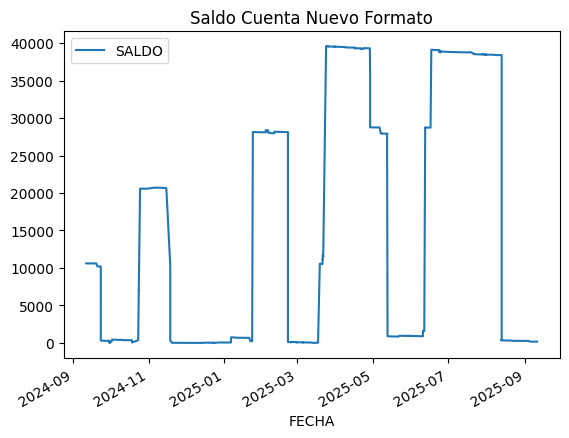

In [27]:
df_nuevo.plot(x='FECHA', y='SALDO', title='Saldo Cuenta Nuevo Formato')

In [30]:
todos= obtener_todas_cuentas(config_new_file)

Leyendo archivo nuevo: cuentas/nuevo/Movimientos_cuenta_20240910_20250910.xlsx
Encabezados encontrados en la fila 5 (Excel)
-----------COMPARANDO DATOS NUEVOS CON ANTERIORES
Rango común de fechas: 2024-09-11 → 2025-06-27
SALDO INICIAL: Nuevo [10616.64] Anterior [10618.63]
SALDO FINAL: Nuevo [38851.25 38837.28 38832.78] Anterior [38851.25 38837.28 38832.78]

=== Filas NUEVAS ===
NUEVA (fecha 2024-10-31): {'FECHA': Timestamp('2024-10-31 00:00:00'), 'SALDO': 20578.27, 'DEBITO': 0.0, 'CREDITO': 1.34}
NUEVA (fecha 2024-11-29): {'FECHA': Timestamp('2024-11-29 00:00:00'), 'SALDO': 22.19, 'DEBITO': 0.0, 'CREDITO': 0.08}

No hay fechas eliminadas.

=== Cambios en fechas comunes (2024-09-11 → 2025-06-27) ===
FECHA 2024-09-11 – Columna 'SALDO': antiguo=10618.63, nuevo=10616.64
FECHA 2024-09-17 – Columna 'SALDO': antiguo=10612.13, nuevo=10610.14
FECHA 2024-09-19 – Columna 'SALDO': antiguo=10608.47, nuevo=10606.48
FECHA 2024-09-20 – Columna 'SALDO': antiguo=10207.26, nuevo=10205.27
FECHA 2024-09-23

### Lectura Cuenta

In [31]:
# df_cuenta,datos_extra = leer_todos_csv("cuentas")
# df_cuenta = leer_cuenta_nuevo(path)

df_cuenta= obtener_todas_cuentas(config_new_file)

df_importantes= filtrar_importantes(df_cuenta) #para ver lo importante

df_cuenta= df_cuenta[(~df_cuenta["DESCRIPCION"].str.contains("INTERES A SU FAVOR", na=False))&( ~df_cuenta["DESCRIPCION"].str.contains("IVA COBRADO", na=False)) &( ~df_cuenta["DESCRIPCION"].str.contains("COMISION", na=False))]


Leyendo archivo nuevo: cuentas/nuevo/Movimientos_cuenta_20240910_20250910.xlsx
Encabezados encontrados en la fila 5 (Excel)
-----------COMPARANDO DATOS NUEVOS CON ANTERIORES
Rango común de fechas: 2024-09-11 → 2025-06-27
SALDO INICIAL: Nuevo [10616.64] Anterior [10618.63]
SALDO FINAL: Nuevo [38851.25 38837.28 38832.78] Anterior [38851.25 38837.28 38832.78]

=== Filas NUEVAS ===
NUEVA (fecha 2024-10-31): {'FECHA': Timestamp('2024-10-31 00:00:00'), 'SALDO': 20578.27, 'DEBITO': 0.0, 'CREDITO': 1.34}
NUEVA (fecha 2024-11-29): {'FECHA': Timestamp('2024-11-29 00:00:00'), 'SALDO': 22.19, 'DEBITO': 0.0, 'CREDITO': 0.08}

No hay fechas eliminadas.

=== Cambios en fechas comunes (2024-09-11 → 2025-06-27) ===
FECHA 2024-09-11 – Columna 'SALDO': antiguo=10618.63, nuevo=10616.64
FECHA 2024-09-17 – Columna 'SALDO': antiguo=10612.13, nuevo=10610.14
FECHA 2024-09-19 – Columna 'SALDO': antiguo=10608.47, nuevo=10606.48
FECHA 2024-09-20 – Columna 'SALDO': antiguo=10207.26, nuevo=10205.27
FECHA 2024-09-23

In [35]:
probar_validez_saldo(df_cuenta)

Saldo incorrecto en 2024-04-01 00:00:00: esperado 2046.1, encontrado 2058.79
Saldo Ant 2086.1, Saldo Act 2058.79, MONTO -40.0
DIFERENCIA 12.690000000000055


Saldo incorrecto en 2024-06-11 00:00:00: esperado 2479.86, encontrado 2483.41
Saldo Ant 2482.86, Saldo Act 2483.41, MONTO -3.0
DIFERENCIA 3.549999999999727


Saldo incorrecto en 2024-06-12 00:00:00: esperado 2479.41, encontrado 2476.41
Saldo Ant 2486.41, Saldo Act 2476.41, MONTO -7.0
DIFERENCIA -3.0


Saldo incorrecto en 2024-09-09 00:00:00: esperado 10625.65, encontrado 10627.25
Saldo Ant 10625.88, Saldo Act 10627.25, MONTO -0.23
DIFERENCIA 1.6000000000003638


Saldo incorrecto en 2024-09-11 16:12:00: esperado 10614.88, encontrado 10616.64
Saldo Ant 10618.63, Saldo Act 10616.64, MONTO -3.75
DIFERENCIA 1.7600000000002183


Saldo incorrecto en 2024-10-01 08:33:00: esperado 65.82, encontrado 67.81
Saldo Ant 69.32, Saldo Act 67.81, MONTO -3.5
DIFERENCIA 1.990000000000009


Saldo incorrecto en 2024-11-05 21:13:00: esperado 20708.93, e

## Tarjeta

### Lectura Tarjeta

In [54]:
# generar_csv_tarjeta("tarjeta/xlsBanca/Agosto25.xls")

In [38]:
datos_tarjetas,df_tarjetas=leer_tarjetas()
df_tarjetas.sort_values(by='FECHA', inplace=True)
df_tarjetas = df_tarjetas[df_tarjetas["FECHA"].notna()]  # Filtrar filas con fechas válidas
df_tarjetas["ACUMULADO"]=df_tarjetas["VALOR"].cumsum()

Leyendo 19 archivos de tarjetas en tarjeta\datos


C:\Users\andre\AppData\Local\Temp\ipykernel_46712\3908740991.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_resumen_total = pd.concat(resúmenes, ignore_index=True)
C:\Users\andre\AppData\Local\Temp\ipykernel_46712\3908740991.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_movimientos_total = pd.concat(movimientos, ignore_index=True)


## Notion

In [100]:
df_notion = leer_notion()

df_notion = df_notion[(df_notion["Valor"]!=0)&(df_notion["DESCRIPCION_NOTION"].notna())]



# Marcar Variables

### Marcar Pago Madre

In [39]:

df_pagos_marcado =df_cuenta.copy()
df_pagos_marcado["FECHA"] = df_pagos_marcado["FECHA"].dt.normalize()
pagosMensualMa:list[PAGO]=[
    PAGO(monto=132,inicio='2024-10-02'),
    PAGO(monto=135,inicio='2024-11-05'),
    
    PAGO(monto=100,inicio="2025-01-06"),
    PAGO(monto=50,inicio ="2025-02-24"),
    PAGO(monto=100,inicio="2025-03-21"),
    PAGO(monto= 100,inicio="2025-04-23"),
    PAGO(monto=110,inicio="2025-05-22"),
    PAGO(monto=100,inicio="2025-06-24"),
    PAGO(monto=50,inicio="2025-07-28"),

]
for pago in pagosMensualMa:
    df_pagos_marcado.loc[df_pagos_marcado["FECHA"] == pago.inicio, "PAGOS_MENSUAL_MA"] = pago.monto

#2024-04-26
#2024-09-25 572

pagosMa:list[PAGO]=[
    PAGO(monto=401,inicio="2024-09-20"),
    PAGO(monto=249,inicio='2024-10-02'),
    # PAGO(monto=300,inicio='2024-12-22'),
    PAGO(monto=600,inicio ="2025-01-06"),
    PAGO(monto=200,inicio="2025-02-10"),
    PAGO(monto=535,inicio="2025-03-21"),

    PAGO(monto=728,inicio="2025-06-10",descripcion="Gasolina300 y Pago428"),#gasolina 300
]
for pago in pagosMa:
    df_pagos_marcado.loc[df_pagos_marcado["FECHA"] == pago.inicio, "PAGOS_MA"] = pago.monto


df_pagos_marcado[df_pagos_marcado["PAGOS_MENSUAL_MA"].notna() | df_pagos_marcado["PAGOS_MA"].notna() ][["FECHA","DESCRIPCION","DEBITO","CREDITO","PAGOS_MENSUAL_MA","PAGOS_MA"]]

,FECHA,DESCRIPCION,DEBITO,CREDITO,PAGOS_MENSUAL_MA,PAGOS_MA
146,2024-09-20,07550945-MASTERCARD -RECAUDACIONES-2230670...,401.21,0.00,NaN,401.0
163,2024-10-02,TRANSFERENCIA DIRECTA DE ARCINIEGA BASANTES PA...,0.00,249.00,132.0,249.0
164,2024-10-02,TRANSFERENCIA DIRECTA DE ARCINIEGA BASANTES PA...,0.00,132.00,132.0,249.0
190,2024-11-05,TRANSFERENCIA DIRECTA DE ARCINIEGA BASANTES PA...,0.00,132.00,135.0,NaN
221,2025-01-06,PAGO TARJETA INTERBANCARIA ENVIADA,1.26,0.00,100.0,600.0
222,2025-01-06,TRANSFERENCIA DIRECTA DE ARCINIEGA BASANTES PA...,0.00,440.00,100.0,600.0
223,2025-01-06,TRANSFERENCIA DIRECTA DE ARCINIEGA BASANTES PA...,0.00,160.00,100.0,600.0
224,2025-01-06,TRANSFERENCIA DIRECTA DE ARCINIEGA BASANTES PA...,0.00,100.00,100.0,600.0
274,2025-02-10,TRANSFERENCIA INTERBANCARIA A GREGORY ALESSAND...,9.75,0.00,NaN,200.0
275,2025-02-10,TRANSFERENCIA DIRECTA DE ARCINIEGA BASANTES PA...,0.00,200.00,NaN,200.0


### Marcar Inversiones

In [40]:

ver_inversiones(df_pagos_marcado) 
inversiones:list[PAGO] = [  # ES CUANDO TENGO INVERSION EN MI CUENTA
    # PAGO(monto=3177, fin="2024-03-18"),
    # PAGO(monto=26000,fin="2024-03-28"),
    # PAGO(monto=10278, inicio="2024-05-29",fin="2024-06-04"),
    # PAGO(monto=10476,inicio='2024-09-04',fin='2024-09-23'),
    # PAGO(monto=9876,fin="2024-09-23"),
    # PAGO(monto=6675,inicio="2024-10-24",fin="2024-11-18"),
    # PAGO(monto=10003,inicio="2024-11-18",fin="2024-11-18"),
    # PAGO(monto = 13_536,inicio="2024-10-24",fin="2024-11-18"),
    # PAGO(monto=27_897,inicio="2025-01-24",fin="2025-02-21"),
    # PAGO(monto=10_530, inicio="2025-03-19", fin="2025-04-28"),
    # PAGO(monto=28_137, inicio="2025-03-24"),
    # PAGO(monto=600,inicio="2025-03-21"), #mi deposito
    # PAGO(monto=290,inicio="2025-02-03",fin="2025-02-05"),
    
    # PAGO(monto=26000,inicio="2024-03-28",fin="2025-01-24"), #1897

    # PAGO(monto=10100,fin="2024-05-29"),
    # PAGO(monto =10278, inicio="2024-06-04",fin="2024-09-04"),

    PAGO(monto=26000,fin='2024-03-28'),

    PAGO(monto=10272,inicio='2024-05-29',fin='2024-06-04'),
    
    # PAGO(monto=10468,inicio="2024-09-04"), # LA DIVIDO EN LAS DE ABAJO POR pago tarjeta  #sobran 592
    PAGO(monto=6648, inicio='2024-09-04', fin="2024-09-23"), #
    PAGO(monto=3228, inicio='2024-09-04', fin="2024-09-23"), #le pague la tarjeta a madre 

    PAGO(monto=6675, inicio="2024-10-24",fin="2024-11-18"),
    PAGO(monto=13536, inicio="2024-10-25",fin="2024-11-18"), #combinamos las 2 me faltan 100


    PAGO(monto=27897, inicio="2025-01-24",fin="2025-02-21"), #complete de mi dinero para los 28k
    PAGO(monto=-103,inicio="2025-02-21",fin="2025-03-24"), #el dinero que complete para los 28k

    PAGO(monto=290, inicio="2025-02-03", fin='2025-02-05'), #hermana me para guardar
    # PAGO(monto=10530, inicio="2025-03-19"), #creo que pague tarjeta a madre
    PAGO(monto=3213, inicio="2025-03-19",fin="2025-04-28"), #TARJETA
    PAGO(monto=7317, inicio="2025-03-19",fin='2025-04-28'), #RESTO INVERSION

    PAGO(monto=27000, inicio="2025-03-24",fin='2025-05-12'),
    PAGO(monto=1034, inicio="2025-03-24"), #El resto de la inversion
    PAGO(monto=27120, inicio="2025-06-12",fin="2025-08-12"), #mi deposito

    PAGO(monto=10389.95, inicio="2025-06-17",fin="2025-08-12"), #mi deposito




    PAGO(monto=-600, fin="2025-03-21"), #Simular dinero que tenia en efectivo y despues deposite

]
df_inversiones_marcado = marcar_fijos(df_pagos_marcado, inversiones, "INVERSION")



------INVERSIONES
        FECHA              DESCRIPCION     MONTO
15 2024-03-28  CERTIFICADO DE DEPOSITO -26000.00
0  2024-05-29   CANCELACION PLAZO FIJO  10100.00
16 2024-06-04  CERTIFICADO DE DEPOSITO -10278.00
1  2024-09-04   CANCELACION PLAZO FIJO  10278.00
17 2024-09-23  CERTIFICADO DE DEPOSITO  -6648.00
2  2024-10-24   CANCELACION PLAZO FIJO   6648.00
3  2024-10-24   CANCELACION PLAZO FIJO     27.48
4  2024-10-25   CANCELACION PLAZO FIJO  12854.21
5  2024-10-25   CANCELACION PLAZO FIJO    682.63
19 2024-11-18  CERTIFICADO DE DEPOSITO -10003.00
18 2024-11-18  CERTIFICADO DE DEPOSITO -10310.00
6  2025-01-24   CANCELACION PLAZO FIJO  26000.00
7  2025-01-24   CANCELACION PLAZO FIJO   1897.57
20 2025-02-21  CERTIFICADO DE DEPOSITO -28000.00
8  2025-03-19   CANCELACION PLAZO FIJO  10310.00
9  2025-03-19   CANCELACION PLAZO FIJO    225.25
11 2025-03-24   CANCELACION PLAZO FIJO    139.84
10 2025-03-24   CANCELACION PLAZO FIJO  28000.00
21 2025-04-28  CERTIFICADO DE DEPOSITO  -7317.00
22

In [ ]:
# ver_fecha_dudosa("2025-02-21",df_suavizado,tipo="cuenta",numero_filas=10)

### Obtener y Marcar Pagos Tarjeta

In [ ]:
pagos_tarjeta = obtener_pagos_tarjetas(df_cuenta)
df_tarjeta_marcado = marcar_fijos(df_unido_notion, pagos_tarjeta, "PAGO_TARJETA",incluir_ultimo=True)

                  FECHA     SALDO  \
17  2024-03-18 00:00:00  28113.78   
19  2024-03-18 00:00:00  27826.40   
73  2024-06-20 00:00:00   1993.48   
100 2024-07-22 00:00:00   1727.28   
113 2024-08-06 00:00:00   1440.21   
122 2024-08-21 00:00:00   1259.80   
146 2024-09-20 18:29:00  10205.27   
193 2024-11-15 09:35:00  20622.09   
196 2024-11-19 22:03:00     22.11   
238 2025-01-21 09:35:00    661.36   
241 2025-01-22 07:31:00    242.84   
280 2025-02-21 09:33:00  28120.00   
317 2025-03-21 09:33:00  10525.09   
324 2025-03-21 23:28:00  11434.29   
378 2025-04-21 09:40:00  39249.14   
402 2025-05-07 09:53:00  27947.79   
490 2025-06-23 11:39:00  38995.30   
491 2025-06-23 12:06:00  38779.20   
535 2025-07-21 20:20:00  38544.44   
536 2025-07-21 09:34:00  38524.44   
574 2025-08-21 09:32:00    288.22   

                                           DESCRIPCION  DEBITO  CREDITO  \
17                 02469497-MASTERCARD -RA-22306700008  510.98      0.0   
19                 02469497-MASTERC

# Agrupar Por dia

### Cuenta

In [ ]:
df_dias_unicos = df_inversiones_marcado.copy()
df_dias_unicos = df_dias_unicos.groupby("FECHA").agg({
    "DEBITO": "sum",
    "CREDITO": "sum",
    "PAGOS_MENSUAL_MA": "last",
    "PAGOS_MA": "last",
    # "PAGO_TARJETA": "last",
    # "TARJETA OTRAS": "sum",
    "INVERSION": "last",
    "SALDO": "last",
    "MONTO": "sum",
}).reset_index()

In [42]:
probar_validez_saldo(df_dias_unicos)

Probando validez de saldos... con diferencia permitida de  1
Saldo incorrecto en 2024-04-01 00:00:00: esperado 2034.1, encontrado 2046.79
Saldo Ant 2086.1, Saldo Act 2046.79, MONTO -52.0
DIFERENCIA 12.690000000000055


Saldo incorrecto en 2024-06-11 00:00:00: esperado 2482.86, encontrado 2486.41
Saldo Ant 2482.86, Saldo Act 2486.41, MONTO 0.0
DIFERENCIA 3.549999999999727


Saldo incorrecto en 2024-06-12 00:00:00: esperado 2479.41, encontrado 2476.41
Saldo Ant 2486.41, Saldo Act 2476.41, MONTO -7.0
DIFERENCIA -3.0


Saldo incorrecto en 2024-09-09 00:00:00: esperado 10620.779999999999, encontrado 10622.38
Saldo Ant 10625.88, Saldo Act 10622.38, MONTO -5.1
DIFERENCIA 1.6000000000003638


Saldo incorrecto en 2024-09-11 00:00:00: esperado 10614.88, encontrado 10616.64
Saldo Ant 10622.38, Saldo Act 10616.64, MONTO -7.5
DIFERENCIA 1.7600000000002183


Saldo incorrecto en 2024-10-01 00:00:00: esperado 65.82, encontrado 67.81
Saldo Ant 69.32, Saldo Act 67.81, MONTO -3.5
DIFERENCIA 1.99000000000

### Notion

In [101]:
notion_agrupado_dia=df_notion.groupby("FECHA_REAL").agg({
    "NOTION": "sum",
    #agregar todos las descripciones
    "DESCRIPCION_NOTION": lambda x: '-|-'.join(x),
    "NOTIONCUM": "last"
})
notion_agrupado_dia["DESCRIPCION_NOTION"] = notion_agrupado_dia["DESCRIPCION_NOTION"] + notion_agrupado_dia["NOTION"].apply(lambda x: f" (${x})")
df_unido_notion = df_dias_unicos.merge(notion_agrupado_dia, left_on='FECHA', right_index=True, how='outer', suffixes=('', '_NOTION'))

### Unir 

In [132]:

INICIO = obtener_primer_dia_valido(pagos_tarjeta, datos_tarjetas)
# datos_tarjetas_posibles = [dato for dato in datos_tarjetas if pd.to_datetime(dato["fecha"]) < fecha_inicial]
# for dato in datos_tarjetas_posibles:
    # print(f"Fecha: {dato['fecha']}, Total: {dato['total_sin_datos_extra']}")

PRIMER PAGO DE TARJETA EN CUENTA:
-----------------
         FECHA                          DESCRIPCION    MONTO     SALDO
14 2024-03-18               TRANSFERENCIA INTERNET     3.00  31783.76
15 2024-03-18  02469497-MASTERCARD -RA-54660500091 -3177.00  28606.76
16 2024-03-18               TRANSFERENCIA INTERNET    18.00  28624.76
17 2024-03-18  02469497-MASTERCARD -RA-22306700008  -510.98  28113.78
18 2024-03-18               TRANSFERENCIA INTERNET   223.60  28337.38
19 2024-03-18  02469497-MASTERCARD -RA-22306700008  -510.98  27826.40
---------------

PRIMER PAGO TARJETA DESDE LA CUENTA PAGO(monto=np.float64(510.98), inicio='2024-03-18', fin=None, descripcion=None)

DATOS DE LA TARJETA:
-----------------
 fecha_emision            2024-03-06 00:00:00
fecha_pago               2024-03-21 00:00:00
total_a_pagar_despues                 510.98
Name: 1, dtype: object
---------------

Fecha de inicio: 2024-02-06 00:00:00


In [143]:
# #si primero cuenta: desde que comienzo a consumir la tarjeta
# # si primero tarjeta: primer consumo tarjeta del primer pago
# primerPagoTarjeta = pagos_tarjeta[0].inicio
# anio, mes, dia = primerPagoTarjeta.split("-")
# dia = int(dia)
# mes = int(mes)
# print(primerPagoTarjeta)
# if dia<6 or dia>21:
#     print("ERRROR PAGUE FUERA DE PLAZO. NO SE COMO FUNCIONA")

# fechaInicial = f"{anio}-{mes-1}-06"
# fechaInicial = pd.to_datetime(fechaInicial)
# print(fechaInicial)

df_interpolar_tarjeta = unir_pagos_tarjeta(df_tarjeta_marcado,df_tarjetas)
df_interpolar_tarjeta = ajustar_tarjeta_fecha_inicial(df_interpolar_tarjeta, INICIO)
df_interpolar_tarjeta["TARJETA"] = df_interpolar_tarjeta["ACUMULADO"]

df_interpolar_tarjeta.tail(10)

# df_interpolar_tarjeta.fillna()  # Rellenar NaN con 0

,FECHA,DEBITO,CREDITO,PAGOS_MENSUAL_MA,PAGOS_MA,INVERSION,SALDO,MONTO,NOTION,DESCRIPCION_NOTION,NOTIONCUM,PAGO_TARJETA,VALOR,ACUMULADO,TARJETA
350,2025-08-21,20.00,0.0,NaN,NaN,1034.0,288.22,-20.00,NaN,NaN,NaN,4527.96,NaN,NaN,NaN
351,2025-08-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.00,Uber stav ($23.0),660.74,4527.96,NaN,NaN,NaN
352,2025-09-01,10.15,0.0,NaN,NaN,1034.0,278.17,-10.15,7.00,Doctor-|-Tienda ($7.0),667.74,4527.96,NaN,NaN,NaN
353,2025-09-02,3.25,0.0,NaN,NaN,1034.0,274.92,-3.25,NaN,NaN,NaN,4527.96,NaN,NaN,NaN
354,2025-09-03,3.75,0.0,NaN,NaN,1034.0,271.17,-3.75,NaN,NaN,NaN,4527.96,NaN,NaN,NaN
355,2025-09-04,72.51,0.0,NaN,NaN,1034.0,198.66,-72.51,NaN,NaN,NaN,4527.96,NaN,NaN,NaN
356,2025-09-05,17.74,0.0,NaN,NaN,1034.0,180.92,-17.74,13.74,Enterogermina ($13.74),681.48,4527.96,NaN,NaN,NaN
357,2025-09-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.00,Pago Majo ($20.0),701.48,4527.96,NaN,NaN,NaN
358,2025-09-09,3.25,0.0,NaN,NaN,1034.0,177.67,-3.25,NaN,NaN,NaN,4527.96,NaN,NaN,NaN
359,2025-09-10,4.00,0.0,NaN,NaN,1034.0,173.67,-4.00,NaN,NaN,NaN,4527.96,NaN,NaN,NaN


### Visualizar Union Tarjeta

In [144]:

# Crear figura
fig = go.Figure()
df= datos_tarjetas[datos_tarjetas["fecha_emision"] > INICIO].copy()
# 2) Añades primero tu traza de datos_tarjetas (quedará detrás)
df["midpoint"] = (
    df["fecha_emision"] 
    + (df["fecha_pago"] - df["fecha_emision"]) / 2
)
df["width_ms"] = (
    df["fecha_pago"] - df["fecha_emision"]
) / np.timedelta64(1, "ms")

fig.add_trace(go.Bar(
    x=df["midpoint"],
    y=df["total_mes"].cumsum(),
    width=df["width_ms"],
    name="Total a Pagar Después",
    marker_color="orange",
    opacity=0.6  # opcional: bajarle un poco la opacidad
))
fig.add_trace(go.Scatter(
    # x=df_notion[df_notion["Persona"] == "Madre"]["FECHA_REAL"],
    # y=df_notion[df_notion["Persona"] == "Madre"]["VALOR"].cumsum(),
    x=df_notion_madre["FECHA_REAL"],
    y=df_notion_madre["NOTION"].cumsum(),
    mode='markers',
    name='Valores Notion',
    marker=dict(color='blue', size=5),
))



df_temp = df_interpolar_tarjeta.copy()
rango_fechas = pd.date_range(start=df_temp["FECHA"].min(), end=df_temp["FECHA"].max(), freq='D')
df_fechas = pd.DataFrame({"FECHA": rango_fechas})

# Unir para incluir fechas faltantes (sin modificar original)
df_plot = df_fechas.merge(df_temp, on="FECHA", how="left")

# Interpolar sólo para valores faltantes en la columna TARJETA
df_plot["TARJETA"] = df_plot["TARJETA"].interpolate(method="linear")

# Crear gráfico con línea continua y puntos visibles solo donde hay datos reales
bars = go.Scatter(
    x=df_plot["FECHA"],
    y=df_plot["TARJETA"],
    mode="lines+markers",
    name="Pagos Tarjeta",
    line=dict(color="blue", width=2, dash="solid"),
    marker=dict(
        color=["blue" if not np.isnan(val) else "rgba(0,0,255,0.2)" for val in df_temp.set_index("FECHA").reindex(rango_fechas)["TARJETA"]],
        size=6,
        symbol="circle"
    ),
    showlegend=True
)

fig.add_trace(bars)  # Añadir la primera traza de barras

no_nulos = df_interpolar_tarjeta[
    (df_interpolar_tarjeta["PAGO_TARJETA"].notna()) &
    (df_interpolar_tarjeta["PAGO_TARJETA"] != 0)
]
primeros = no_nulos[no_nulos["PAGO_TARJETA"].diff() != 0].copy()

# 2) Crear barra gruesa (ancho en milisegundos: 3 días)
primeros["width_ms"] = 3 * 24 * 60 * 60 * 1000  # 3 días

# 3) Crear la traza
barra_cambios = go.Bar(
    x=primeros["FECHA"],
    y=primeros["PAGO_TARJETA"],
    width=primeros["width_ms"],
    marker=dict(color="rgba(0,0,255,0.3)"),
    name="Primeros Cambios",
    showlegend=True
)
fig.add_trace(barra_cambios)

# fig.add_trace(px.bar(primeros, x="FECHA", y="PAGO_TARJETA", title="Primeros Pagos Tarjeta").data[0])
# Rango de fechas
min_fecha = df_interpolar_tarjeta["FECHA"].min()
max_fecha = df_interpolar_tarjeta["FECHA"].max()

# Crear fechas 8 de cada mes
fechas_8 = pd.date_range(start=min_fecha, end=max_fecha, freq='MS')
fechas_8 = [d + pd.DateOffset(days=5) for d in fechas_8]

# Agregar líneas y anotaciones
for fecha in fechas_8:
    if fecha <= max_fecha:
        fecha_dt = fecha.to_pydatetime()
        # Línea vertical
        fig.add_shape(
            type="line",
            x0=fecha_dt,
            x1=fecha_dt,
            y0=0,
            y1=1,
            xref='x',
            yref='paper',
            line=dict(color="red", width=1, dash="dash")
        )
        # Anotación
        fig.add_annotation(
            x=fecha_dt,
            y=1.02,  # ligeramente arriba del gráfico
            xref='x',
            yref='paper',
            showarrow=False,
            text="Pago Obligatorio",
            font=dict(size=10, color="red"),
            align="left"
        )

#Hacer una linea horizontal continua desde el primer valor cada vez que cambia de valor de PAGO_TARJETA la linea de pago obligatorio anterior Ignorar valores nulos o cero
df_interpolar_tarjeta["PAGO_TARJETA"] = df_interpolar_tarjeta["PAGO_TARJETA"].fillna(0)
df_interpolar_tarjeta["PAGO_TARJETA"] = df_interpolar_tarjeta["PAGO_TARJETA"].replace(0, np.nan)
# Crear líneas horizontales para PAGO_TARJETA
cambios_de_valores = df_interpolar_tarjeta[df_interpolar_tarjeta["PAGO_TARJETA"].notna() & (df_interpolar_tarjeta["PAGO_TARJETA"].diff() != 0)]
for index, row in cambios_de_valores.iterrows():
    fecha = row["FECHA"]
    valor = row["PAGO_TARJETA"]
    if pd.notna(valor) and valor != 0:
        fecha_inicio = (fecha - pd.DateOffset(months=1)).to_pydatetime()

        fig.add_shape(
            type="line",
            x0=fecha,
            x1= fecha_inicio,
            y0=valor,
            y1=valor,
            line=dict(color="blue", width=1, dash="dash"),
            xref='x',
            yref='y'
        )



# Ajustes de layout
fig.update_layout(
    barmode='group',
    xaxis_title="Fecha",
    yaxis_title="Monto"
)

fig.show()


In [70]:
for dato_idx in datos_tarjetas.index:
    dato = datos_tarjetas.loc[dato_idx]
    # print(dato)
    print(f"Fecha Emision: {dato['fecha_emision']} Fecha Pago: {dato['fecha_pago']}")
    print(f"Saldo Anterior:{dato["saldo_anterior"]} Pagado Ant {dato["subtotal_pagado"]} Total Mes: {datos_tarjetas.loc[dato_idx,"total_mes"]}  Total a Pagar: {datos_tarjetas.loc[dato_idx, 'total_a_pagar_despues']}")
    if dato_idx + 1 >= len(datos_tarjetas):
        fecha_emision_siguiente = datos_tarjetas.loc[dato_idx, 'fecha_emision'] + pd.Timedelta(days=30)  # Asumir 30 días si no hay siguiente
    else:
        fecha_emision_siguiente = datos_tarjetas.loc[dato_idx + 1, 'fecha_emision']

    fecha_emision_actual = datos_tarjetas.loc[dato_idx, 'fecha_emision']
    pagos_coincidentes=[pago for pago in pagos_tarjeta if (pd.to_datetime(pago.inicio) > fecha_emision_actual) and (pd.to_datetime(pago.inicio) <= fecha_emision_siguiente)]
    print(f"Pagos coincidentes: {[(pago.inicio,pago.monto) for pago in pagos_coincidentes]}")
    print("Total Pagos: ", sum(pago.monto for pago in pagos_coincidentes))



Fecha Emision: 2024-02-06 00:00:00 Fecha Pago: 2024-02-21 00:00:00
Saldo Anterior:842.83 Pagado Ant 842.83 Total Mes: 86.82000000000001  Total a Pagar: 86.82000000000001
Pagos coincidentes: []
Total Pagos:  0
Fecha Emision: 2024-03-06 00:00:00 Fecha Pago: 2024-03-21 00:00:00
Saldo Anterior:106.22 Pagado Ant 132.27 Total Mes: 537.03  Total a Pagar: 510.98
Pagos coincidentes: [('2024-03-18', np.float64(510.98)), ('2024-03-18', np.float64(510.98))]
Total Pagos:  1021.96
Fecha Emision: 2024-04-06 00:00:00 Fecha Pago: 2024-04-21 00:00:00
Saldo Anterior:510.98 Pagado Ant 1021.96 Total Mes: 343.45  Total a Pagar: -167.53
Pagos coincidentes: []
Total Pagos:  0
Fecha Emision: 2024-05-06 00:00:00 Fecha Pago: 2024-05-21 00:00:00
Saldo Anterior:-175.44 Pagado Ant 0.0 Total Mes: 170.26  Total a Pagar: -5.179999999999978
Pagos coincidentes: []
Total Pagos:  0
Fecha Emision: 2024-06-06 00:00:00 Fecha Pago: 2024-06-21 00:00:00
Saldo Anterior:-4.98 Pagado Ant 0.0 Total Mes: 479.34  Total a Pagar: 474.3

# Suavizado

## Interpolar 

In [ ]:
# df_interpolado_saldo = df_inversiones_marcado.copy()
# df_dias_unicos  =df_inversiones_marcado.groupby("FECHA").sum(numeric_only=True).reset_index()


# fecha_completa = pd.date_range(start=df_dias_unicos['FECHA'].min(), end=df_dias_unicos['FECHA'].max(), freq='D')
# df_completo = df_dias_unicos.set_index('FECHA').reindex(fecha_completa).rename_axis('FECHA').reset_index()
# df_completo.fillna(0,inplace=True)  # Rellenar NaN con 0
# df_completo.tail(20)
# df_dias_unicos = df_completo.copy()

# df_interpolar_tarjeta = interpolar_a_cero(df_dias_unicos, "TARJETA")


# df_interpolar_otras_tarjetas = interpolar_a_cero(df_interpolar_tarjeta, "TARJETA OTRAS")


df_interpolar_pago_mensual = interpolar_a_cero(df_interpolar_tarjeta, "PAGOS_MENSUAL_MA")
# df_interpolar_pago_mensual
df_interpolar_pago_tarjeta_ma = interpolar_a_cero(df_interpolar_pago_mensual, "PAGOS_MA")


df_interpolado = df_interpolar_pago_tarjeta_ma.copy()

# df_interpolado.loc[df_interpolado["FECHA"]>'2024-08-22', "SALDO"] += 1084

# df_interpolado = df_interpolado.ffill()

# df_interpolado["TOTAL"] = df_interpolado["SALDO"] - df_interpolado["TARJETA INTER"] - df_interpolado["TARJETA OTRAS INTER"] -df_interpolado["INVERSION"] + df_interpolado["PAGO_MENSUAL INTER"] + df_interpolar_pago_tarjeta_ma["PAGO_TARJETA_MA INTER"]

MODIFICANDO PAGOS_MENSUAL_MA - FECHAS: DatetimeIndex(['2024-10-02', '2024-11-05', '2025-01-06', '2025-02-24',
               '2025-03-21', '2025-04-23', '2025-05-22', '2025-06-24',
               '2025-07-28'],
              dtype='datetime64[ns]', name='FECHA', freq=None)
Rellenando desde 2024-10-02 00:00:00 hasta 2024-11-04 00:00:00 con valor final 135.0
Ramp: [  0.           4.09090909   8.18181818  12.27272727  16.36363636
  20.45454545  24.54545455  28.63636364  32.72727273  36.81818182
  40.90909091  45.          49.09090909  53.18181818  57.27272727
  61.36363636  65.45454545  69.54545455  73.63636364  77.72727273
  81.81818182  85.90909091  90.          94.09090909  98.18181818
 102.27272727 106.36363636 110.45454545 114.54545455 118.63636364
 122.72727273 126.81818182 130.90909091 135.        ]
Rellenando desde 2024-11-05 00:00:00 hasta 2025-01-05 00:00:00 con valor final 100.0
Ramp: [  0.           1.63934426   3.27868852   4.91803279   6.55737705
   8.19672131   9.83606557  

## Suavizar fechas importantes

In [ ]:
def suavizar_fechas():
    df_suavizado = df_interpolado.copy()
    # df_suavizado = df_interpolar_tarjeta.copy()

    # erroresManuales= ["2024-10-25","2025-02-28","2025-03-31","2025-04-30","2025-01-31",'2025-02-21',"2025-04-30","2024-05-13"]
    erroresManuales = []

    # erroresAutomaticos = df_cuenta[df_cuenta["DESCRIPCION"].str.contains("INTERES A SU FAVOR", na=False)]["FECHA"].astype(str).tolist()

    inversiones_fechas = [inversion.inicio for inversion in inversiones if inversion.inicio is not None] + [inversion.fin for inversion in inversiones if inversion.fin is not None]
    pago_mensual_fechas = [pago.inicio for pago in pagosMensualMa if pago.inicio is not None]
    pago_tarjetas_ma_fechas = [pago.inicio for pago in pagosMa if pago.inicio is not None]
    # tarjetas_marcado_fechas = df_tarjeta_marcado[~df_tarjeta_marcado ["TARJETA"].isna()]["FECHA"].astype(str).tolist()
    tarjetas_marcado_fechas = []
    # fechas_a_suavizar = erroresManuales +  inversiones_fechas + pago_mensual_fechas + pago_tarjetas_ma_fechas + tarjetas_marcado_fechas 

    fechas_a_suavizar = []
    fechas_a_suavizar.sort()
    print(f"Fechas a suavizar: {fechas_a_suavizar}")
    df_suavizado = df_suavizado[~df_suavizado["FECHA"].astype(str).isin(fechas_a_suavizar)].copy()
    df_suavizado.sort_values(by='FECHA', inplace=True)
    df_suavizado = df_suavizado.reset_index(drop=True)



In [145]:
df_suavizado = df_interpolado.copy()

In [57]:
df_suavizado["DESCRIPCION_NOTION"].fillna("", inplace=True)
df_suavizado.ffill(inplace=True)  # Rellenar NaN con el valor anterior
df_suavizado["TOTAL"] = df_suavizado["SALDO"] - df_suavizado["TARJETA"] + df_suavizado["PAGO_TARJETA"]  - df_suavizado["INVERSION"] + df_suavizado["PAGOS_MENSUAL_MA INTER"] + df_suavizado["NOTIONCUM"].fillna(0)



C:\Users\andre\AppData\Local\Temp\ipykernel_46712\465448805.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





# Sacar Diferencias

In [58]:


df_diferencia = df_suavizado.copy()

df_diferencia["TOTAL_MADRE"] = df_diferencia["PAGOS_MENSUAL_MA"]+ df_diferencia["PAGOS_MA"]
df_diferencia["diff_madre"] = df_diferencia["TOTAL_MADRE"].diff()

df_diferencia["TOTAL_MADRE INTER"] = df_diferencia["PAGOS_MENSUAL_MA INTER"]+ df_diferencia["PAGOS_MA INTER"]
df_diferencia["diff_madre INTER"] = df_diferencia["TOTAL_MADRE INTER"].diff()

df_diferencia['diff_days']   =df_diferencia['FECHA'].diff().dt.days
df_diferencia["diff_total"] = df_diferencia["TOTAL"].diff()
df_diferencia['diff_total_dias'] = df_diferencia['diff_total'] / df_diferencia['diff_days']

df_diferencia["diff_tarjeta"] = df_diferencia["TARJETA"].diff()
df_diferencia["diff_tarjeta_dias"] = df_diferencia["diff_tarjeta"] / df_diferencia["diff_days"]

df_diferencia["saldo_sin_inversion"] = df_diferencia["SALDO"] - df_diferencia["INVERSION"]
df_diferencia["diff_saldo_sin_inversion"] = df_diferencia["saldo_sin_inversion"].diff()

# df_diferencia["saldo_real"] = df_diferencia["SALDO"] - df_diferencia["INVERSION"] + df_diferencia["PAGO_TARJETA"]
# df_diferencia["diff_saldo_real"] = df_diferencia["saldo_real"].diff()

df_diferencia["diff_pago_tarjeta"] = df_diferencia["PAGO_TARJETA"].diff()

df_diferencia["TARJETA_REAL"] = df_diferencia["TARJETA"] - df_diferencia["PAGO_TARJETA"].fillna(0)
df_diferencia["diff_tarjeta_real"] = df_diferencia["TARJETA_REAL"].diff()

# df_suavizado["SALDO"] - df_suavizado["TARJETA"] + df_suavizado["PAGO_TARJETA"]  - df_suavizado["INVERSION"] + df_suavizado["PAGO_MENSUAL INTER"] + df_suavizado["PAGO_TARJETA_MA INTER"]

# df_diferencia["total_yo"] = df_diferencia["SALDO"] - df_diferencia["TARJETA"] + df_diferencia["PAGO_TARJETA"]  - df_diferencia["INVERSION"] + df_diferencia["NOTIONCUM"]
# df_diferencia["diff_total_yo"] = df_diferencia["total_yo"].diff()
# df_diferencia["diff_total_yo_dias"] = df_diferencia["diff_total_yo"] / df_diferencia['diff_days']

df_diferencia["diff_notion"] = df_diferencia["NOTIONCUM"].diff()

df_diferencia["diff_TOTAL"] = df_diferencia["TOTAL"].diff()
df_diferencia["diff_TOTAL_dias"] = df_diferencia["diff_TOTAL"] / df_diferencia['diff_days']





# Extraer Descripciones

In [59]:
PATH_ATIPICOS_DESCRIPCIONES = "guardarCompleto/atipicos_descripciones.xlsx"

PATH_GUARDAR_COMPLETO_ATIPICOS = "guardarCompleto/diferencias_atipicas"

COLUMNAS_GUARDADAS = ["FECHA", "diff_TOTAL", "diff_tarjeta", "diff_saldo_sin_inversion","DESCRIPCION","DESCRIPCION_NOTION","comentario","MADRE"]
PATH_COMPLETO = "guardarCompleto"




In [77]:
# PATH_ATIPICOS_DESCRIPCIONES = "guardarCompleto/diferencias_atipicas/prueba_2025-07-21.xlsx"

In [60]:
df_descripciones_2=pd.read_excel(PATH_ATIPICOS_DESCRIPCIONES)
# df_descripciones_2=pd.read_excel('guardarCompleto/diferencias_atipicas/prueba_2025-09-10.xlsx')
df_descripciones_2["FECHA"] = pd.to_datetime(df_descripciones_2["FECHA"])
df_descripciones_2= df_descripciones_2[COLUMNAS_GUARDADAS].copy()
df_dif_desc_2 = df_diferencia.merge(df_descripciones_2, on='FECHA', how='left', suffixes=('', '_desc2'))
df_dif_desc_2
df_dif_desc = df_dif_desc_2.copy()
df_dif_desc["DESCRIPCION"] = df_dif_desc_2["DESCRIPCION"].fillna("")
df_dif_desc["MADRE"] = df_dif_desc_2["MADRE"].fillna("")


# df_atipicos= df_dif_desc[df_dif_desc["diff_TOTAL"] > 20].copy()



# Visualizar

## scatter normal

<Axes: title={'center': 'TOTAL Suavizado'}, xlabel='FECHA', ylabel='TOTAL'>

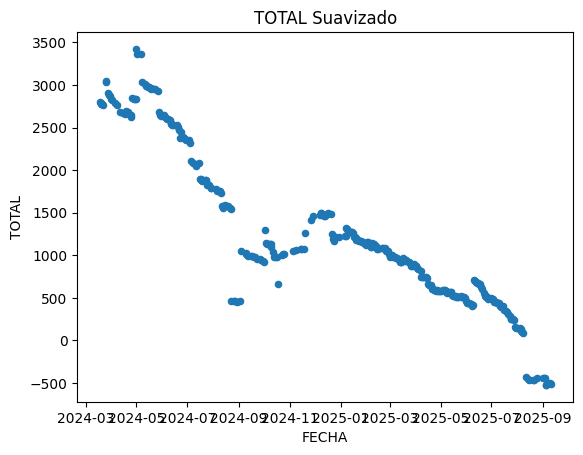

In [196]:
df_suavizado.plot.scatter(x="FECHA", y="TOTAL", title="TOTAL Suavizado")

In [ ]:
ver_fecha_dudosa("2025-06-10",df_dif_desc,numero_filas=10,tipo="suavizado")[["FECHA","PAGOS_MA INTER","TOTAL"]]

Fecha objetivo: 2025-06-10


KeyError: "['PAGOS_TARJETA_MA INTER'] not in index"

## Visualizacion Completa

In [1]:
class Trace:
    def __init__(self,tipo,name, y, x="FECHA", mode='lines+markers', line_color='blue', hovertemplate=None, text=None):
        self.x = x
        self.y = y
        self.name = name
        self.mode = mode
        self.line_color = line_color
        self.hovertemplate = hovertemplate
        self.text = text
        self.tipo = tipo
    

class Graficos:
    traces = []
    highlighted_days=[]
    fig = go.Figure()
    max_fecha = None
    def __init__(self, df):
        self.df = df
        self.max_fecha = df['FECHA'].max()


    def add_trace(self, trace: Trace):
        self.traces.append(trace)
    
    def delete_trace(self, trace: Trace):
        self.traces.remove(trace)

    def add_8_days(self):
        for fecha in fechas_8:
            if fecha <= max_fecha:
                fecha_dt = fecha.to_pydatetime()
                # Línea vertical
                self.fig.add_shape(
                    type="line",
                    x0=fecha_dt,
                    x1=fecha_dt,
                    y0=0,
                    y1=1,
                    xref='x',
                    yref='paper',
                    line=dict(color="gray", width=1, dash="dash")
                    
    )
    def add_last_day_card(self):
        max_fecha = df_tarjetas["FECHA"].max()
        if max_fecha is None:
            print("No hay fechas disponibles para agregar la última línea de tarjeta.")
            return
        fecha_dt = pd.to_datetime(max_fecha).to_pydatetime()
        self.fig.add_shape( 
            type="line",
            x0=fecha_dt,
            x1=fecha_dt,
            y0=0,
            y1=1,
            xref='x',
            yref='paper',
            line=dict(color="blue", width=1, dash="dash")
        )


    def add_highlighteds_day(self, fechas):
        fechas = pd.to_datetime(fechas)
        for fecha in fechas:
            if fecha <= max_fecha:
                fecha_dt = pd.to_datetime(fecha).to_pydatetime()
                self.fig.add_vline(
                    x=fecha_dt,
                    line_width=2,
                    line_dash="dash",  # Estilo: "solid", "dot", "dash"
                    line_color="red"
                )

    def show_pendiente(self, inicio=None, fin=None):
        if inicio is None:
            inicio = self.df['FECHA'].min()
        if fin is None:
            fin = self.df['FECHA'].max()

        inicio = pd.to_datetime(inicio)
        fin = pd.to_datetime(fin)

        df_total_inicio = self.df[self.df['FECHA'] == inicio]
        df_total_fin = self.df[self.df['FECHA'] == fin]
        if df_total_inicio.empty or df_total_fin.empty:
            print("No se encontraron datos para las fechas especificadas.")
            print(df_total_inicio, df_total_fin)
            return
        total_inicio = df_total_inicio['TOTAL'].values[0]
        total_fin = df_total_fin['TOTAL'].values[0]
        pendiente = (total_fin - total_inicio) / (fin - inicio).days
        print(f"Pendiente entre {inicio.strftime('%Y-%m-%d')} y {fin.strftime('%Y-%m-%d')}: {pendiente:.2f} por día")
        print(f"Total {total_fin} - {total_inicio} = {total_fin - total_inicio}")

        # Agregar línea de pendiente al gráfico
        self.fig.add_shape(
            type="line",
            x0=inicio,
            y0=total_inicio,
            x1=fin,
            y1=total_fin,
            line=dict(color="blue", width=2, dash="dash"),
            name="Pendiente"
        )


        

    def plot(self):
        print(self.traces)
        for trace in self.traces:
            if trace.tipo == 'scatter':
                self.fig.add_trace(go.Scatter(
                    x=self.df[trace.x],
                    y=self.df[trace.y],
                    mode=trace.mode,
                    name=trace.name,
                    line=dict(color=trace.line_color),
                    hovertemplate=trace.hovertemplate,
                    text=trace.text
                ))
            elif trace.tipo == 'bar':
                self.fig.add_trace(go.Bar(
                    x=self.df[trace.x],
                    y=self.df[trace.y],
                    name=trace.name,
                    marker_color=trace.line_color,
                    hovertemplate=trace.hovertemplate,
                    text=trace.text
                ))
        self.fig.show()

# total_yo = Trace(
#     tipo='scatter',
#     name='Total Yo',
#     y='total_yo',
#     hovertemplate='<b>%{x}</b><br>Valor: %{y}<br>Descripción: %{text}',
#     text=df_dif_desc['descripcion'].fillna('') + " | " + df_dif_desc["madre"]
# )
total = Trace(
    tipo='scatter',
    name='Total',
    y='TOTAL',
    hovertemplate='<b>%{x}</b><br>Valor: %{y}<br>Descripción: %{text}',
    text=df_dif_desc['DESCRIPCION'] + " | " + df_dif_desc["MADRE"],
    line_color='red'
)
total_tarjeta = Trace(
    tipo='scatter',
    name='Total Tarjeta',
    y='TARJETA_REAL',
    line_color='blue',
    mode='lines+markers',
    hovertemplate='<b>%{x}</b><br>Valor: %{y}<br>Descripción: %{text}',
    text=df_dif_desc['DESCRIPCION'] + " | " + df_dif_desc["MADRE"],
)
total_cuenta = Trace(
    tipo='scatter',
    name='Total Cuenta (sin inversiones)',
    y="saldo_sin_inversion",
    line_color='green',
    mode='lines+markers',
    hovertemplate='<b>%{x}</b><br>Valor: %{y}<br>Descripción: %{text}',
    text=df_dif_desc['DESCRIPCION'].fillna('') + " | " + df_dif_desc["MADRE"],
)

diff_saldo_sin_inversion = Trace(
    tipo='bar',
    name='Diferencia Saldo (sin inversiones)',
    y='diff_saldo_sin_inversion',
    line_color='green',
    hovertemplate='<b>%{x}</b><br>Diferencia: %{y:.2f}<br>Descripción: %{text}',
    text=df_dif_desc['DESCRIPCION'].fillna('') + " | " + df_dif_desc["MADRE"],
)
diff_tarjeta = Trace(
    tipo='bar',
    name='Diferencia Tarjeta',
    y='diff_tarjeta',
    line_color='blue',
    hovertemplate='<b>%{x}</b><br>Diff: %{y}<br>Descripción: %{text}',
    text=df_dif_desc['DESCRIPCION'].fillna('') + " | " + df_dif_desc["MADRE"],
)
diff_notion = Trace(
    tipo='bar',
    name='Diferencia Notion',
    y='diff_notion',
    line_color='black',
    hovertemplate='<b>%{x}</b><br>Diff Notion: %{y}<br>Descripción: %{text}',
    text=df_dif_desc['DESCRIPCION_NOTION'].fillna('')
)
# inversiones =Trace(
#     tipo='bar',
#     name='Inversiones',
#     y='INVERSION',
#     line_color='purple',
#     hovertemplate='<b>%{x}</b><br>Inversiones: %{y}<br>Descripción: %{text}',
#     text=df_dif_desc['descripcion'].fillna('') + " | " + df_dif_desc["madre"],
# )
total_madre = Trace(
    tipo='scatter',
    name='Total Madre',
    y='TOTAL_MADRE',
    line_color='gray',
    mode='lines+markers',
)
interpolado_mensual = Trace(
    tipo='scatter',
    name='Interpolado Mensual Madre',
    y='PAGOS_MENSUAL_MA INTER',
    line_color='purple',
    mode='lines+markers',
    hovertemplate='<b>%{x}</b><br>Pago Mensual: %{y}<br>Descripción: %{text}',
    text=df_dif_desc['DESCRIPCION'] + " | " + df_dif_desc["MADRE"],
)
notion = Trace(
    tipo='scatter',
    name='Notion',
    y='NOTIONCUM',
    line_color='black',
    mode='lines+markers',
    hovertemplate='<b>%{x}</b><br>Notion: %{y}<br>Descripción: %{text}',
    text=df_dif_desc['DESCRIPCION_NOTION'].fillna('') + " :" + df_dif_desc["NOTION"].astype(str) ,
)


highlighted_days = [
    '2024-06-22',
    '2024-09-30',
    '2025-03-22',
    "2025-01-31",
    "2025-07-18"
]
df_ajustado_gasolina = df_dif_desc.copy()
df_ajustado_gasolina.loc[df_ajustado_gasolina["FECHA"] < '2025-06-10', "TOTAL"] += 300
# Crear instancia de Graficos
grafico = Graficos(df_ajustado_gasolina)
# Agregar trazas
# grafico.add_trace(total_yo)
grafico.add_trace(total)
grafico.add_trace(total_tarjeta)
grafico.add_trace(total_cuenta)

grafico.add_trace(diff_saldo_sin_inversion)
grafico.add_trace(diff_tarjeta)
grafico.add_trace(diff_notion)

# grafico.add_trace(total_madre)
grafico.add_trace(notion)

grafico.add_trace(interpolado_mensual)
# Agregar días destacados
grafico.add_highlighteds_day(highlighted_days)
# Agregar líneas de 8 días
grafico.add_8_days()
# Mostrar pendiente
inicio = '2024-09-30'
fin = '2025-07-04'
# grafico.show_pendiente(inicio, fin)
grafico.show_pendiente('2025-01-08', '2025-06-10')
grafico.show_pendiente('2025-01-08', '2025-07-28')
grafico.show_pendiente('2025-06-10', '2025-07-28')
# grafico.show_pendiente('2024-05-01', '2024-08-22')
# grafico.show_pendiente('2024-05-01', '2025-01-08')
grafico.add_last_day_card()

grafico.plot()


#pendiente de la linea

#FIXING INVERSIONES

NameError: name 'go' is not defined

In [84]:
df_dif_desc[df_dif_desc["DESCRIPCION"].str.contains("asolina", na=False)][["FECHA","TOTAL","diff_TOTAL","diff_tarjeta","diff_saldo_sin_inversion","diff_notion","DESCRIPCION","DESCRIPCION_NOTION","MADRE"]].sort_values(by="FECHA")

,FECHA,TOTAL,diff_TOTAL,diff_tarjeta,diff_saldo_sin_inversion,diff_notion,DESCRIPCION,DESCRIPCION_NOTION,MADRE
141,2024-10-05,1130.052727,-15.909091,20.00,0.00,0.0,Gasolina,,
187,2025-01-17,1210.858333,-54.748333,52.79,-3.00,0.0,Gasolina 20 y Pagado ale 26,,
239,2025-03-26,888.315000,-25.125000,15.00,-13.25,0.0,Gasolina.Almuerzo y luces reparadas.,,
247,2025-04-03,850.475000,-20.225000,15.00,-8.35,0.0,Gasolina .comida?,,
249,2025-04-07,813.465000,-25.635000,30.01,-5.00,0.0,gasolina,,
281,2025-05-15,531.178571,-33.791429,31.47,-16.25,10.0,GoogleOne2 Gasolina29. Corte 12,Corte ($10.0),?
293,2025-06-01,457.420000,-39.970000,46.22,0.00,0.0,GoogleCloud14 Gasolina30,,
301,2025-06-10,713.235000,302.735000,0.00,723.61,-424.0,PagadoGasolina300 PagadoMadre428,Pagado ($-424.0),Gasolina300 Pago428
320,2025-07-04,454.621515,-33.934848,30.49,-4.96,0.0,Gasolina 30,,
332,2025-07-21,306.569091,-29.904848,28.92,-274.82,3.5,Gasolina 29. Pago Tarjeta 268,Llanta desinflada ($3.5),


In [88]:
df_dif_desc[(df_dif_desc["diff_TOTAL"] < -10)& (df_dif_desc["FECHA"] > '2025-06-01') & (df_dif_desc["FECHA"] < '2025-08-06')][["FECHA","TOTAL","diff_TOTAL","diff_tarjeta","diff_saldo_sin_inversion","diff_notion","DESCRIPCION","DESCRIPCION_NOTION","MADRE"]].sort_values(by="diff_TOTAL")

,FECHA,TOTAL,diff_TOTAL,diff_tarjeta,diff_saldo_sin_inversion,diff_notion,DESCRIPCION,DESCRIPCION_NOTION,MADRE
338,2025-07-29,155.350000,-83.250000,0.00,-83.25,0.00,Transferencia 80 buseta viaje.,,No pagado
329,2025-07-16,361.833333,-41.364848,31.64,-11.24,0.00,31 Salida con Renata. Uber y 3l. Comida 11,,
311,2025-06-22,559.205000,-41.290000,68.54,0.00,21.00,,Uber Condado trafico-|-Mc Condado -|-Ubers Tra...,
312,2025-06-23,518.950000,-40.255000,0.00,-288.29,8.81,RegaloMela16 Trago5 Flores18 nose8 pagotarjeta236,Papas ($8.81),
309,2025-06-19,624.360000,-38.870000,4.20,-40.92,0.00,Salida Renata PelotaComidaRegalo 40,,
320,2025-07-04,454.621515,-33.934848,30.49,-4.96,0.00,Gasolina 30,,
334,2025-07-24,255.724545,-30.574848,39.84,-9.25,17.00,40 Super. Y comida con Noah,Super jugos ... ($17.0),14 Super
332,2025-07-21,306.569091,-29.904848,28.92,-274.82,3.50,Gasolina 29. Pago Tarjeta 268,Llanta desinflada ($3.5),
325,2025-07-11,408.637576,-28.734848,21.00,-9.25,0.00,Vulkano21,,
316,2025-06-27,483.725455,-27.054848,24.94,-21.97,18.34,Salida Renata PelotaComidaRegalo 40,Gotas Ojos ($18.34),


In [91]:
ver_fecha_dudosa('2025-06-22', df_dif_desc, tipo="tarjeta", numero_filas=5,justo=True)

Fecha objetivo: 2025-06-22
TOTAL: 68.53999999999999


,FECHA,DESCRIPCION,VALOR,OPERACION,Periodo,ACUMULADO
390,2025-06-22,KSH DLOCAL ARCOS DORAD E,6.60,CONSUMO,2025-07,4444.22
375,2025-06-22,RET IVA SERV DIGITAL 100%,0.50,N/D,2025-07,4444.72
374,2025-06-22,DLC*UBER RIDES INT P,3.34,CONSUMO,2025-07,4448.06
383,2025-06-22,DLC*UBER RIDESAN S,2.54,CONSUMO,2025-07,4450.60
384,2025-06-22,RET IVA SERV DIGITAL 100%,0.38,N/D,2025-07,4450.98
385,2025-06-22,COLORIN COLORADO SAS Q,24.00,CONSUMO,2025-07,4474.98
373,2025-06-22,AUTOSERVIPAMPA CIA. LT Q,31.18,CONSUMO,2025-07,4506.16


In [87]:
df_tarjetas.query("FECHA < '2025-02-01' & VALOR > 100")
df_cuenta.query("FECHA < '2025-02-01' & MONTO < -100")
df_notion.query("FECHA_REAL < '2025-01-10'" ).sort_values(by="FECHA_REAL")

,DESCRIPCION_NOTION,Valor,Tipo,Valor real,Persona,PERSONA_NOTION,FECHA_CREACION,FECHA_REAL,NOTION,NOTIONCUM
0,Pago dermatologo 30/9,210,Doy,210,Madre (https://www.notion.so/Madre-160975b322a...,Madre,2024-11-19 22:07:00,2024-09-30,210.00,210.00
1,Medicamentos 23/10,"20,82",Doy,"20,82",Madre (https://www.notion.so/Madre-160975b322a...,Madre,2024-11-24 10:00:00,2024-10-23,20.82,230.82
2,Banco Seguro,45,Doy,45,Madre (https://www.notion.so/Madre-160975b322a...,Madre,2024-11-19 22:12:00,2024-11-14,45.00,275.82
3,Inversion,100,Doy,100,Madre (https://www.notion.so/Madre-160975b322a...,Madre,2024-11-29 22:26:00,2024-11-18,100.00,375.82
11,Prestado,130,Doy,130,Madre (https://www.notion.so/Madre-160975b322a...,Madre,2024-11-19 22:29:00,2024-11-19,130.00,560.32
10,Doctor,"8,5",Doy,"8,5",Madre (https://www.notion.so/Madre-160975b322a...,Madre,2024-11-19 22:28:00,2024-11-19,8.50,430.32
8,Buffalo,6,Doy,6,Madre (https://www.notion.so/Madre-160975b322a...,Madre,2024-11-19 22:19:00,2024-11-19,6.00,405.82
9,Kfc,16,Doy,16,Madre (https://www.notion.so/Madre-160975b322a...,Madre,2024-11-19 22:24:00,2024-11-19,16.00,421.82
6,Milanesa Uber,7,Doy,7,Ñaña (https://www.notion.so/a-a-9207ce82fad14c...,Ñaña,2024-11-19 22:18:00,2024-11-19,7.00,7.00
5,Gotas,8,Doy,8,Madre (https://www.notion.so/Madre-160975b322a...,Madre,2024-11-19 22:17:00,2024-11-19,8.00,389.82


## Visualizacion total_yo + total_madre vs total

In [58]:
fig = go.Figure()
# fig.add_trace(go.Bar(
#     x=df_diferencia['FECHA'],
#     y=df_diferencia["PAGO_TARJETA"],
#     # mode='lines+markers',
#     name='PAGOS CUENTA TARJETA',
#     # line=dict(color='blue')
# ))
# fig.add_trace(go.Bar(
#     x=df_diferencia['FECHA'],
#     y=df_diferencia["TARJETA"],
#     # mode='lines+markers',
#     name='PAGOS TARJETA',
#     # line=dict(color='red')
# ))

fig.add_trace(go.Scatter(
    x=df_diferencia['FECHA'],
    y=df_diferencia["total_yo"],
    mode='lines+markers',
    name='TOTAL YO',
    line=dict(color='blue')
))

# fig.add_trace(go.Scatter(
#     x=df_diferencia['FECHA'],
#     y=df_diferencia["PAGO_MENSUAL INTER"],
#     mode='lines+markers',
#     name='DIFERENCIA TOTAL MADRE',
#     line=dict(color='red')
# ))
# fig.add_trace(go.Scatter(
#     x=df_diferencia['FECHA'],
#     y=df_diferencia["PAGO_TARJETA_MA INTER"],
#     mode='lines+markers',
#     name='DIFERENCIA TOTAL TARJETA MA',
#     line=dict(color='green')
# ))
# fig.add_trace(go.Scatter(
#     x=df_diferencia['FECHA'],
#     y=df_diferencia["TOTAL_MADRE"],
#     mode='lines+markers',
#     name='DIFERENCIA TOTAL',
#     line=dict(color='orange')
# ))
fig.add_trace(go.Scatter(
    x=df_diferencia['FECHA'],
    y=df_diferencia["total_yo"]+df_diferencia["TOTAL_MADRE"],
    mode='lines+markers',
    name='TOTAL + Madre',
    line=dict(color='purple')
))
fig.add_trace(go.Scatter(
    x=df_diferencia['FECHA'],
    y=df_diferencia["TOTAL"],
    mode='lines+markers',
    name='TOTAL',
    line=dict(color='black')
))

In [59]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_diferencia['FECHA'],
    y=df_diferencia['total_yo'],
    mode='lines+markers',
    name='Diferencia diaria',
    line=dict(color='blue')
))
fig.add_trace(go.Bar(
    x=df_diferencia['FECHA'],
    y=-df_diferencia['diff_saldo_real'],
    name='Diferencia Total Real',
    marker_color='orange',
    hovertemplate='Fecha: %{x|%Y-%m-%d}<br>Diferencia Total Real: %{y}<extra></extra>',
    base=df_diferencia['total_yo']  # Empieza desde el valor de TOTAL
))
fig.add_trace(go.Bar(
    x=df_diferencia['FECHA'],
    y=df_diferencia['diff_tarjeta'],
    name='Diferencia Total Yo',
    marker_color='green',
    hovertemplate='Fecha: %{x|%Y-%m-%d}<br>Diferencia Total Yo: %{y}<extra></extra>',
    base=df_diferencia['total_yo']  # Empieza desde el valor de TOTAL
))


## Visualizar Diferencias

In [62]:
# df_diferencia[''] = df_diferencia['diff_amount'].apply(lambda x: 'positivo' if x > 0 else 'negativo')


# df_atipicos = df_diferencia.copy()
df_atipicos=df_dif_desc
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_atipicos['FECHA'],
    y=df_atipicos['diff_TOTAL'],
    mode='markers',
    name='Δ TOTAL',
    line=dict(color='red'),
    hovertemplate='<b>%{x}</b><br>Valor: %{y}<br>Descripción: %{text}',
    text=df_atipicos['DESCRIPCION'] + " | " + df_atipicos["MADRE"]
))

fig.add_trace(go.Bar(
    x=df_atipicos['FECHA'],
    y=-df_atipicos['diff_tarjeta'],
    name='Δ Tarjeta',
    marker_color='blue',
    text=df_atipicos['DESCRIPCION'].fillna('') + " | " + df_atipicos["MADRE"].fillna(''),
    hovertemplate='<b>%{x}</b><br>Tarjeta: %{y}<br>Descripción: %{text}',
))
fig.add_trace(go.Bar(
    x=df_atipicos['FECHA'],
    y=df_atipicos["diff_saldo_sin_inversion"],
    name='Δ Saldo',
    marker_color='green',
    text=df_atipicos['DESCRIPCION'] + " | " + df_atipicos["MADRE"],
    hovertemplate='<b>%{x}</b><br>Saldo: %{y}<br>Descripción: %{text}',
))
fig.add_trace(go.Bar(
    x=df_atipicos['FECHA'],
    y=-df_atipicos["diff_notion"],
    name='Δ Notion',
    marker_color='black',
    text=df_atipicos['DESCRIPCION_NOTION'].fillna('') + " | " + df_atipicos["NOTION"].fillna(0).astype(str),
))
#lineas horizontales en 20 y -20
fig.add_hline(y=10, line_width=1, line_dash="dash", line_color="green", annotation_text="Límite Superior", annotation_position="top left")
fig.add_hline(y=-10, line_width=1, line_dash="dash", line_color="red", annotation_text="Límite Inferior", annotation_position="bottom left")
#FIXING INVERSIONES

In [63]:
fecha = '2025-02-25'
tipo='cuenta'
# tipo="tarjeta"
# tipo="suavizado"
df=ver_fecha_dudosa(fecha, df_dif_desc,15, tipo,justo=True)
df
# df_dif_desc.query("FECHA == @fecha")
# df["DESCRIPCION"].iloc[1]

# df[["FECHA","DESCRIPCION","DESCRIPCION_NOTION","SALDO","TARJETA","PAGO_TARJETA","INVERSION","PAGOS_MENSUAL_MA INTER","NOTIONCUM","TOTAL"]]
# df_atipicos[df_atipicos["FECHA"] == fecha][["FECHA","DEBITO","CREDITO","SALDO","INVERSION","total_yo","diff_total_yo","diff_tarjeta","diff_saldo_real","descripcion"]]

Fecha objetivo: 2025-02-25
TOTAL: -17.23


C:\Users\andre\AppData\Local\Temp\ipykernel_46712\2501121670.py:15: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



,FECHA,MONTO,SALDO,DESCRIPCION
290,2025-02-25 14:08:00,-17.23,130.51,TRANSFERENCIA DIRECTA A ROMAN GUERRERO FREDDY ...


In [243]:
df_cuenta[df_cuenta["DESCRIPCION"].str.contains("ERIK", na=False)&(df_cuenta["FECHA"] >= "2025-02-01")][["FECHA","DESCRIPCION","MONTO","SALDO"]]

,FECHA,DESCRIPCION,MONTO,SALDO
523,2025-07-11 17:27:00,TRANSFERENCIA INTERBANCARIA A ERIKA CRISTINA D...,-2.75,38766.75
567,2025-08-14 13:37:00,TRANSFERENCIA INTERBANCARIA A ERIKA CRISTINA D...,-2.75,357.37


In [ ]:
# df_suavizado["SALDO"] - df_suavizado["TARJETA"] + df_suavizado["PAGO_TARJETA"]  - df_suavizado["INVERSION"] + df_suavizado["PAGOS_MENSUAL_MA INTER"] + df_suavizado["NOTIONCUM"].fillna(0)


In [124]:
df_notion[df_notion["FECHA_REAL"] >= '2025-02-10'][["FECHA_REAL","NOTION","NOTIONCUM","DESCRIPCION_NOTION"]]

,FECHA_REAL,NOTION,NOTIONCUM,DESCRIPCION_NOTION
47,2025-02-10,-200.00,419.91,Pagado
48,2025-02-20,20.00,439.91,Majo
49,2025-02-20,7.00,446.91,Chat Gpt Febrero
50,2025-03-02,1.14,448.05,Pan
51,2025-03-04,0.00,448.05,Comida
...,...,...,...,...
115,2025-08-25,23.00,571.49,Uber stav
116,2025-09-01,3.00,574.49,Doctor
117,2025-09-01,4.00,578.49,Tienda
118,2025-09-05,13.74,592.23,Enterogermina


In [167]:
df_cuenta[df_cuenta["DESCRIPCION"].str.contains("RAMOS SALAZAR ANDREA", na=False)]["DESCRIPCION"].values


array(['TRANSFERENCIA DIRECTA A RAMOS SALAZAR ANDREA PATRICIA'],
      dtype=object)

In [179]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import datetime

# Widgets
fecha = widgets.DatePicker(
    description='Fecha:',
    value=datetime.date.today()
)

seleccion = widgets.Dropdown(
    options=['tarjeta', 'cuenta', 'suavizado'],
    description='Selecciona:',
    value='cuenta'
)

opcional = widgets.BoundedIntText(
    value=5,
    min=0,
    max=30,
    description='Entero (opcional):',
    placeholder='Deja en blanco si no aplica'
)

boton = widgets.Button(
    description='Enviar',
    button_style='success'
)

salida = widgets.Output()

# Función de evento
def on_submit(b):
    with salida:
        clear_output()
        df=ver_fecha_dudosa(fecha.value.strftime('%Y-%m-%d'), df_diferencia, 5, tipo=seleccion.value)
        print(df)

# Conectar botón al evento
boton.on_click(on_submit)

# Mostrar el formulario
display(fecha, seleccion, opcional, boton, salida)


DatePicker(value=datetime.date(2025, 7, 28), description='Fecha:', step=1)

Dropdown(description='Selecciona:', index=1, options=('tarjeta', 'cuenta', 'suavizado'), value='cuenta')

BoundedIntText(value=5, description='Entero (opcional):', max=30)

Button(button_style='success', description='Enviar', style=ButtonStyle())

Output()

# Guardar

## Guardar Completo

In [89]:
def guardar_archivo(df,nombre,atipico,guardar_unido=False):
    fecha_actual = pd.to_datetime('today').strftime('%Y-%m-%d')

    df_imprimir = df[COLUMNAS_GUARDADAS].copy()
    df_imprimir["FECHA"] = df_imprimir["FECHA"].dt.strftime('%Y-%m-%d')
    df_imprimir["diff_TOTAL"] = df_imprimir["diff_TOTAL"].round(2)
    df_imprimir["diff_tarjeta"] = df_imprimir["diff_tarjeta"].round(2)
    df_imprimir["diff_saldo_sin_inversion"] = df_imprimir["diff_saldo_sin_inversion"].round(2)

    if(atipico):
        df_imprimir = df_imprimir[df_imprimir["diff_TOTAL"].abs() > 10].copy()
        path = f"{PATH_GUARDAR_COMPLETO_ATIPICOS}/{nombre}_{fecha_actual}.xlsx" 
        if guardar_unido:
            df_imprimir.to_excel(PATH_ATIPICOS_DESCRIPCIONES, index=False)
            print("Sobreescribiendo en:", PATH_ATIPICOS_DESCRIPCIONES)
    else:
        path = f"{PATH_COMPLETO}/{nombre}_{fecha_actual}.xlsx"
    
    # Guardar en formato compatible con Excel (.xlsx)
    
    df_imprimir.to_excel(path, index=False)
    print("Guardado en:", path)

In [90]:
guardar_archivo(df_dif_desc,"prueba",atipico=True,guardar_unido=True)

Sobreescribiendo en: guardarCompleto/atipicos_descripciones.xlsx
Guardado en: guardarCompleto/diferencias_atipicas/prueba_2025-09-11.xlsx


In [1010]:
ver_fecha_dudosa('2025-07-22',df_dif_desc,tipo="tarjeta",justo=False)

Fecha objetivo: 2025-07-22
TOTAL: 0.0


,FECHA,DESCRIPCION,VALOR,OPERACION,Periodo,ACUMULADO
373,2025-06-22,AUTOSERVIPAMPA CIA. LT Q,31.18,CONSUMO,2025-07,4499.56
390,2025-06-22,KSH DLOCAL ARCOS DORAD E,6.60,CONSUMO,2025-07,4506.16
391,2025-06-27,Spotify P380A6D3E5 S,3.49,CONSUMO,2025-07,4509.65
360,2025-06-27,SUPERMAXI INAQUITO LC Q,2.59,CONSUMO,2025-07,4512.24
367,2025-06-27,FYBECA Q,18.34,CONSUMO,2025-07,4530.58
392,2025-06-27,RET IVA SERV DIGITAL 100%,0.52,N/D,2025-07,4531.10
376,2025-07-01,DLC*UBER RIDES INT P,3.99,CONSUMO,2025-07,4535.09
377,2025-07-01,RET IVA SERV DIGITAL 100%,0.60,N/D,2025-07,4535.69


# Extras

<Axes: title={'center': 'Saldo de la Cuenta Bancaria a lo largo del tiempo'}, xlabel='FECHA'>

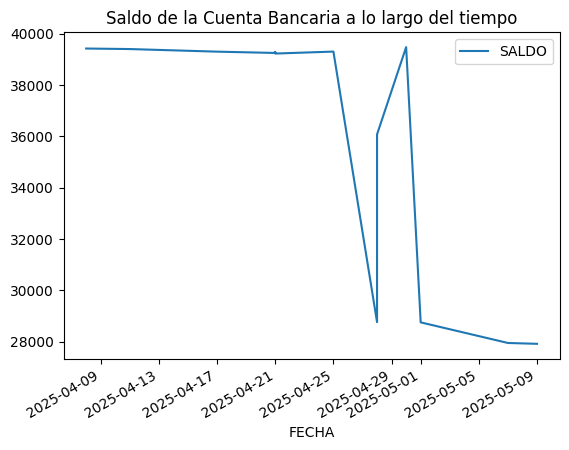

In [ ]:
df_limpio.plot(x='FECHA', y='SALDO', kind='line', title='Saldo de la Cuenta Bancaria a lo largo del tiempo')

In [ ]:


# Datos originales
data = {
    'Fecha': ["21-Feb", "24-Feb", "28-Feb", "14-Mar", "17-Mar", "19-Mar", "21-Mar", "24-Mar", "31-Mar",
              "4-Apr", "11-Apr", "16-Apr", "17-Apr", "21-Apr", "23-Apr", "25-Apr", "28-Apr",
              "1-May", "7-May", "9-May", "12-May", "16-May", "22-May"],
    'Cuenta': [430.91, 468.13, 401.71, 295.24, 322.42, 319.21, 285.44, 259.32, 97.39,
               13.79, -157.43, -318.19, -340.16, -445.4, -506.64, -552.02, -600.67,
               -652.69, -743.72, -769.83, -772.48, -791.69, -680.00]
               ,
    'Liquido':[115,
150,
92,
8,
40,
40,
299,
300,
233,
203.65,
127.36,
34.41,
26,
-25,
43.89,
28.64,
20,
8,
-792,
-825,
-838.00,
-871,
-780,
]
}

# Crear DataFrame
df = pd.DataFrame(data)
df['Fecha_dt'] = pd.to_datetime(df['Fecha'] + '-2025', format='%d-%b-%Y')
df = df.set_index('Fecha_dt').sort_index()
df



,Fecha,Cuenta,Liquido
Fecha_dt,,,
2025-02-21,21-Feb,430.91,115.00
2025-02-24,24-Feb,468.13,150.00
2025-02-28,28-Feb,401.71,92.00
2025-03-14,14-Mar,295.24,8.00
2025-03-17,17-Mar,322.42,40.00
2025-03-19,19-Mar,319.21,40.00
2025-03-21,21-Mar,285.44,299.00
2025-03-24,24-Mar,259.32,300.00
2025-03-31,31-Mar,97.39,233.00


In [ ]:
# Añadir año y convertir fechas

# Rellenar fechas faltantes
full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df
df = df.reindex(full_idx)
df





,Fecha,Cuenta,Liquido
2025-02-21,21-Feb,430.91,115.0
2025-02-22,NaN,NaN,NaN
2025-02-23,NaN,NaN,NaN
2025-02-24,24-Feb,468.13,150.0
2025-02-25,NaN,NaN,NaN
...,...,...,...
2025-05-18,NaN,NaN,NaN
2025-05-19,NaN,NaN,NaN
2025-05-20,NaN,NaN,NaN
2025-05-21,NaN,NaN,NaN


In [ ]:

# Interpolación lineal por tiempo
df['Cuenta'] = df['Cuenta'].interpolate(method='time')
df["Liquido"] = df["Liquido"].interpolate(method='time')
df


,Fecha,Cuenta,Liquido
2025-02-21,21-Feb,430.910000,115.000000
2025-02-22,NaN,443.316667,126.666667
2025-02-23,NaN,455.723333,138.333333
2025-02-24,24-Feb,468.130000,150.000000
2025-02-25,NaN,451.525000,135.500000
...,...,...,...
2025-05-18,NaN,-754.460000,-840.666667
2025-05-19,NaN,-735.845000,-825.500000
2025-05-20,NaN,-717.230000,-810.333333
2025-05-21,NaN,-698.615000,-795.166667


In [ ]:
df = df.reset_index()
df["Fecha"] = df["index"]



In [ ]:
data = pd.read_csv("Datos.csv", sep=";", decimal=",")
# data[data["Fecha"].isna()]
#drop nan de la columna Fecha

df = data.dropna(subset=["Fecha"])
df["Fecha"]=pd.to_datetime(df["Fecha"], format="%m/%d/%Y", errors='coerce')
df.set_index("Fecha", inplace=True)

df_fechas_unicas = df.groupby("Fecha").mean(numeric_only=True)
df_interpolando = df_fechas_unicas.reindex(pd.date_range(start=df_fechas_unicas.index.min(), end=df_fechas_unicas.index.max(), freq='D'))
df_interpolando["TOTAL"]= df_interpolando["TOTAL"].interpolate(method='time')
df_interpolando

# df['Cuenta'] = df['Cuenta'].interpolate(method='time')
# df["Liquido"] = df["Liquido"].interpolate(method='time')
# df
df_interpolando.reset_index(inplace=True)
df_interpolando.rename(columns={"index": "Fecha"}, inplace=True)

C:\Users\andre\AppData\Local\Temp\ipykernel_38084\3449988534.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Fecha"]=pd.to_datetime(df["Fecha"], format="%m/%d/%Y", errors='coerce')


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

,Fecha,Saldo Actual,Liquidos,TOTAL,Resta total,Inversiones/Pagos (No ver al final),Unnamed: 6,Unnamed: 7,Unnamed: 8,Descripcion,Tarjeta,DIAS,RESTA,Madre Pago Mensual,Dias,Interpolate,Pagado Madre,Dias.1,Interpolate.1,Unnamed: 19
0,1/22/2025,242.89,242.89,373.218102,0.0,NaN,NaN,NaN,NaN,Pagado Tar,-275.0,56.0,-5.517857,NaN,30.0,31.818182,NaN,58.0,104.027778,130.328102
1,1/24/2025,28130.00,233.00,377.216811,27897.0,NaN,NaN,NaN,27897.0,Inversion,NaN,54.0,-11.035714,NaN,28.0,36.363636,NaN,56.0,118.888889,144.216811
2,2/21/2025,28121.00,224.00,485.408730,27897.0,NaN,NaN,NaN,27897.0,Pago Min Tar,-30.0,26.0,-165.535714,NaN,0.0,100.000000,NaN,28.0,326.944444,261.408730
3,2/21/2025,115.00,115.00,376.408730,0.0,NaN,NaN,NaN,NaN,NaN,NaN,26.0,-165.535714,NaN,0.0,100.000000,NaN,28.0,326.944444,261.408730
4,2/21/2025,152.00,152.00,315.408730,0.0,NaN,NaN,NaN,NaN,Pagado Madre,NaN,26.0,-165.535714,50.0,25.0,2.000000,NaN,28.0,326.944444,163.408730
5,2/24/2025,92.00,92.00,267.146825,0.0,NaN,NaN,NaN,NaN,Despues Viaje,NaN,23.0,-182.089286,NaN,21.0,8.000000,NaN,25.0,349.236111,175.146825
6,2/28/2025,8.00,8.00,218.797619,0.0,NaN,NaN,NaN,NaN,Dos semanas,NaN,19.0,-204.160714,NaN,7.0,36.000000,NaN,21.0,378.958333,210.797619
7,3/14/2025,40.00,40.00,283.575397,0.0,NaN,NaN,NaN,NaN,Pagado,NaN,5.0,-281.410714,NaN,4.0,42.000000,NaN,7.0,482.986111,243.575397
8,3/17/2025,10575.00,40.00,293.313492,10535.0,NaN,10535.0,NaN,NaN,Inversion Acabada,NaN,2.0,-297.964286,NaN,2.0,46.000000,NaN,4.0,505.277778,253.313492
9,3/19/2025,11434.00,299.00,292.748917,11135.0,600.0,10535.0,NaN,NaN,Pagado madre,-309.0,47.0,-16.787234,100.0,31.0,3.225806,535.0,58.0,7.310345,-6.251083


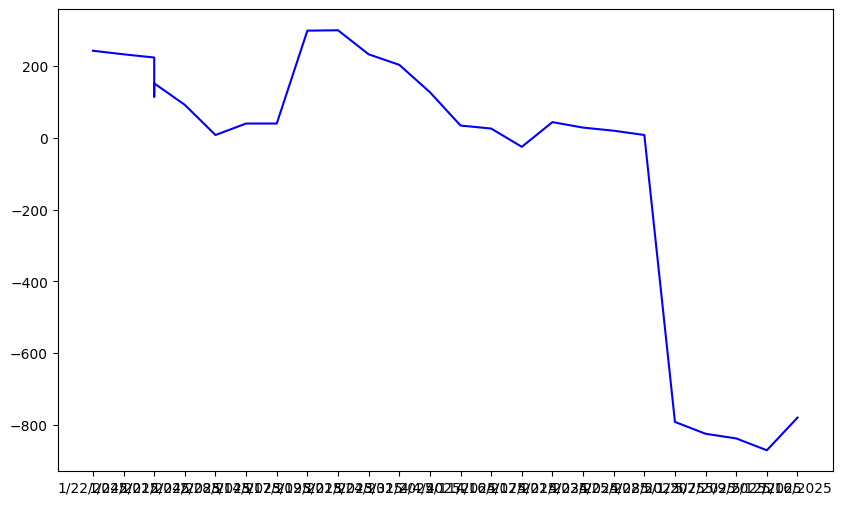

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df["Fecha"],df["Liquidos"], label="Liquido", color='blue')
df

In [ ]:
import numpy as np

array([ -8.42345264, 556.93653473])

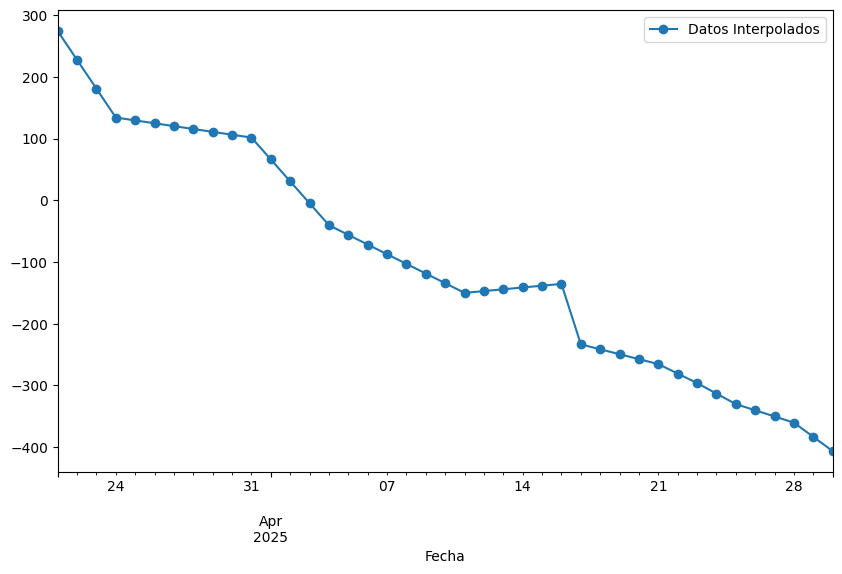

In [ ]:
#graficar
# plt.figure(figsize=(10, 6))
# plt.plot(df_interpolando['Fecha'], df_interpolando['TOTAL'], marker='o', linestyle='-')
# plt.title('Interpolación Lineal de la Cuenta')

x = (df_interpolando['Fecha'] - df_interpolando['Fecha'].min()).dt.days
y = df_interpolando['TOTAL']

# Línea de tendencia lineal
coeffs = np.polyfit(x, y, deg=1)
trend_line = np.poly1d(coeffs)

# Graficar la línea de tendencia
df_interpolando[(df_interpolando['Fecha']>"2025-03-20")&(df_interpolando["Fecha"]<'2025-05-01')].plot(x='Fecha' , y='TOTAL', kind='line', marker='o', linestyle='-', figsize=(10, 6), label='Datos Interpolados')
# plt.plot(df_interpolando['Fecha'], trend_line(x), color='red', linestyle='--', label='Línea de tendencia')
# plt.plot(df_interpolando['Fecha'], df_interpolando['TOTAL'], marker='o', label='Datos originales')
# plt.legend()
coeffs


In [ ]:
#10 mayores perdida de total de un dia para otro
df_interpolando['Diferencia'] = df_interpolando['TOTAL'].diff()
top_losses = df_interpolando.nsmallest(10, 'Diferencia')[['Fecha', 'Diferencia', 'TOTAL',"Saldo Actual"]].copy()
top_losses.sort_index(inplace=True)
top_losses[["Fecha","Diferencia","TOTAL","Saldo Actual"]].sort_index(inplace=True)
top_losses



,Fecha,Diferencia,TOTAL,Saldo Actual
31,2025-02-22,-41.753968,350.654762,NaN
32,2025-02-23,-41.753968,308.900794,NaN
33,2025-02-24,-41.753968,267.146825,92.0
59,2025-03-22,-46.666320,227.270087,NaN
60,2025-03-23,-46.666320,180.603768,NaN
61,2025-03-24,-46.666320,133.937448,39507.0
69,2025-04-01,-35.494653,66.019498,NaN
70,2025-04-02,-35.494653,30.524845,NaN
71,2025-04-03,-35.494653,-4.969809,NaN
85,2025-04-17,-97.935365,-233.404255,39249.0


<Axes: title={'center': 'Cuenta por fecha'}, xlabel='index'>

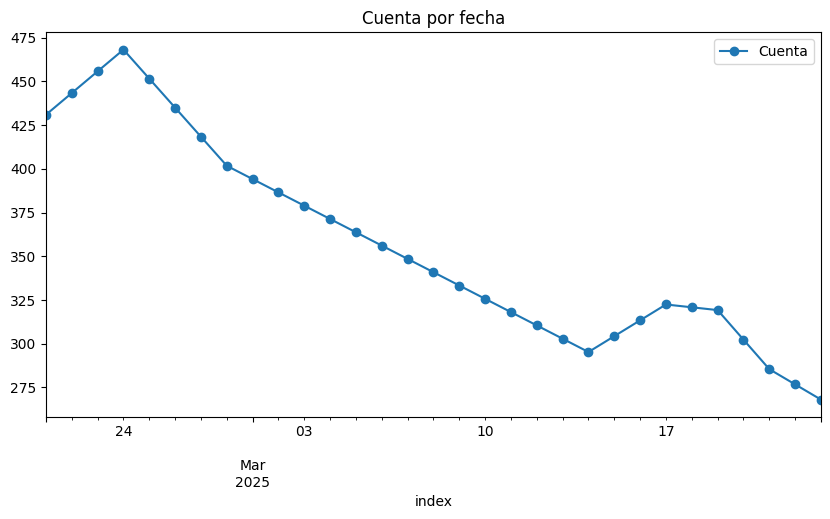

In [ ]:
# Usar el campo 'index' (que contiene las fechas en formato datetime) para filtrar
df[(df["index"] > '2025-02-01') & (df["index"] < '2025-03-24')].plot(x='index', y='Cuenta', title="Cuenta por fecha", figsize=(10, 5), marker='o')

<Axes: title={'center': 'Cuenta por fecha'}, xlabel='index'>

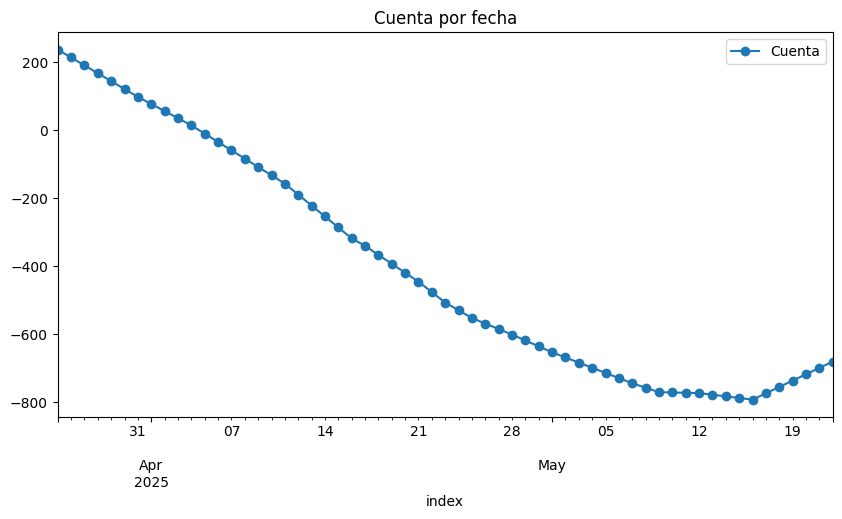

In [ ]:
df[df["index"]>'2025-03-24'].plot(x='index', y='Cuenta', title="Cuenta por fecha", figsize=(10, 5), marker='o')
# plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))

In [ ]:
import numpy as np

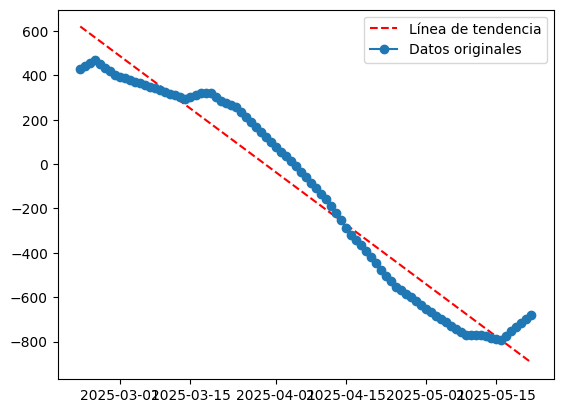

In [ ]:
dfFiltrado =df[(df["index"]>'2025-03-24') & (df["index"]<'2025-05-08')]

x = (df['index'] - df['index'].min()).dt.days
y = df['Cuenta']

# Línea de tendencia lineal
coeffs = np.polyfit(x, y, deg=1)
trend_line = np.poly1d(coeffs)

# Graficar la línea de tendencia
plt.plot(df['index'], trend_line(x), color='red', linestyle='--', label='Línea de tendencia')
plt.plot(df['index'], df['Cuenta'], marker='o', label='Datos originales')
plt.legend()
#plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))

In [ ]:
coeffs

array([-16.83277961, 620.45953297])

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Suponiendo que ya tienes tu DataFrame con todas las fechas interpoladas

# Convertimos fechas a números para usar en regresión lineal
x = (df['index'] - df['index'].min()).dt.days
y = df['Cuenta']

# Ajuste lineal (línea de tendencia)
coeffs = np.polyfit(x, y, deg=1)  # Recta: y = mx + b
trend_line = np.poly1d(coeffs)

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(df['Fecha_dt'], y, label='Cuenta real', linewidth=2)
plt.plot(df['Fecha_dt'], trend_line(x), '--', label='Línea aproximada (tendencia)', linewidth=2)
plt.xlabel('Fecha')
plt.ylabel('Cuenta')
plt.title('Cuenta a lo largo del tiempo con línea de tendencia')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


KeyError: 'index'